20:34:29 │ INFO │ No cache — starting fresh sweep.
20:34:29 │ INFO │ Launching INTERCONNECT …


lumapi imported from:
  C:\Program Files\Lumerical\v202\api\python\lumapi.py

  Data directory : C:\Users\jero0\OneDrive\Escritorio\Github\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_ICNT_cascade_ring_sweep
  HDF5 output    : C:\Users\jero0\OneDrive\Escritorio\Github\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_ICNT_cascade_ring_sweep\ICNT_14Ring_Cascade_UniDir_neff_sweep_V3.h5
  Figures dir    : C:\Users\jero0\OneDrive\Escritorio\Github\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_ICNT_cascade_ring_sweep\figures
  INTERCONNECT 14-Ring Cascade — Parameter Summary  [UNIDIRECTIONAL  V3]
   Ring     R [µm]    λ_res [nm]    neff_TE     ng_TE     κ²_in     κ²_dr     Loss
  ────────────────────────────────────────────────────────────────────────
      1    19.0021     1550.0000   1.609803  2.020543  0.145778  0.143402    101.0  ← SENSOR (swept)
      2    19.1818     1550.0000   1.633303  1.991101  0.145072  0.142672    101.0
      3    19.1934     

20:34:54 │ INFO │   ONA_1 added — 15 input ports configured.
20:34:54 │ INFO │   RING_ 1 added  [unidir, neff=1.609803, L=119.3937 µm]
20:34:54 │ INFO │   RING_ 2 added  [unidir, neff=1.633303, L=120.5228 µm]
20:34:55 │ INFO │   RING_ 3 added  [unidir, neff=1.633121, L=120.5957 µm]
20:34:55 │ INFO │   RING_ 4 added  [unidir, neff=1.632939, L=120.6692 µm]
20:34:56 │ INFO │   RING_ 5 added  [unidir, neff=1.632758, L=120.7427 µm]
20:34:56 │ INFO │   RING_ 6 added  [unidir, neff=1.632576, L=120.8156 µm]
20:34:56 │ INFO │   RING_ 7 added  [unidir, neff=1.632394, L=120.8891 µm]
20:34:57 │ INFO │   RING_ 8 added  [unidir, neff=1.632213, L=120.9620 µm]
20:34:57 │ INFO │   RING_ 9 added  [unidir, neff=1.631974, L=121.9931 µm]
20:34:58 │ INFO │   RING_10 added  [unidir, neff=1.631792, L=122.0666 µm]
20:34:58 │ INFO │   RING_11 added  [unidir, neff=1.631611, L=122.1407 µm]
20:34:58 │ INFO │   RING_12 added  [unidir, neff=1.631430, L=122.2149 µm]
20:34:58 │ INFO │   RING_13 added  [unidir, neff=1.


  Sweep complete — 200 / 200 pts computed
  T_sensor_through_dB  shape : (200, 1000)
  T_final_through_dB   shape : (200, 1000)
  T_drop_dB            shape : (200, 13, 1000)   (RING_2..14 drops)
  drop_power_dBm       shape : (200, 13)
  HDF5                        : C:\Users\jero0\OneDrive\Escritorio\Github\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_ICNT_cascade_ring_sweep\ICNT_14Ring_Cascade_UniDir_neff_sweep_V3.h5


20:43:49 │ INFO │ Saved → drop_power_vs_neff_all.png/pdf
20:43:50 │ INFO │ Saved → sensor_through_sweep_200curves.png/pdf
20:43:54 │ INFO │ Saved → final_through_sweep_200curves.png/pdf
20:44:19 │ INFO │ Saved → drop1_spectrum_heatmap.png/pdf
20:44:52 │ INFO │ Saved → drop13_spectrum_heatmap.png/pdf
C:\Users\jero0\AppData\Local\Temp\ipykernel_18552\3720768563.py:1108: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
20:51:16 │ INFO │ Saved → all_drop_heatmaps_grid.png/pdf
20:51:18 │ INFO │ Saved → power_heatmap_drops_vs_neff.png/pdf
20:51:19 │ INFO │ Saved → resonance_tracking_sensor.png/pdf
20:51:19 │ INFO │ Resonance sensitivity: 772.5621 nm/RIU


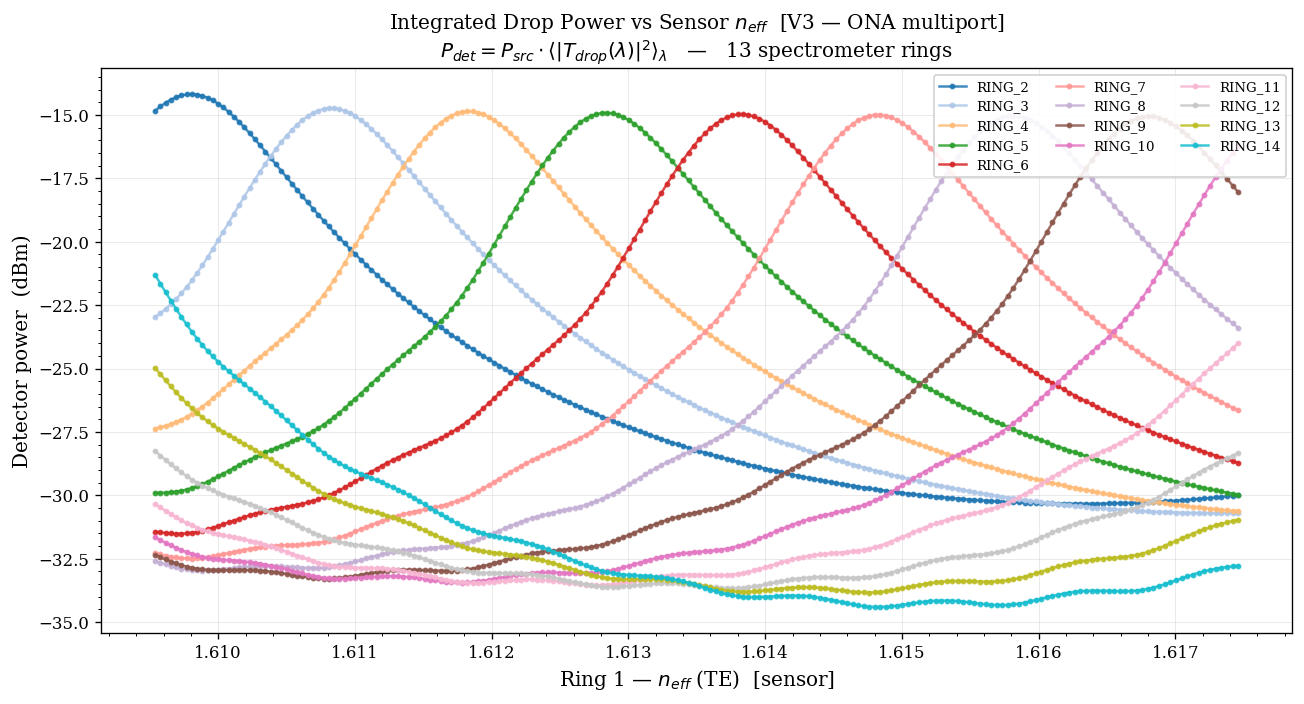

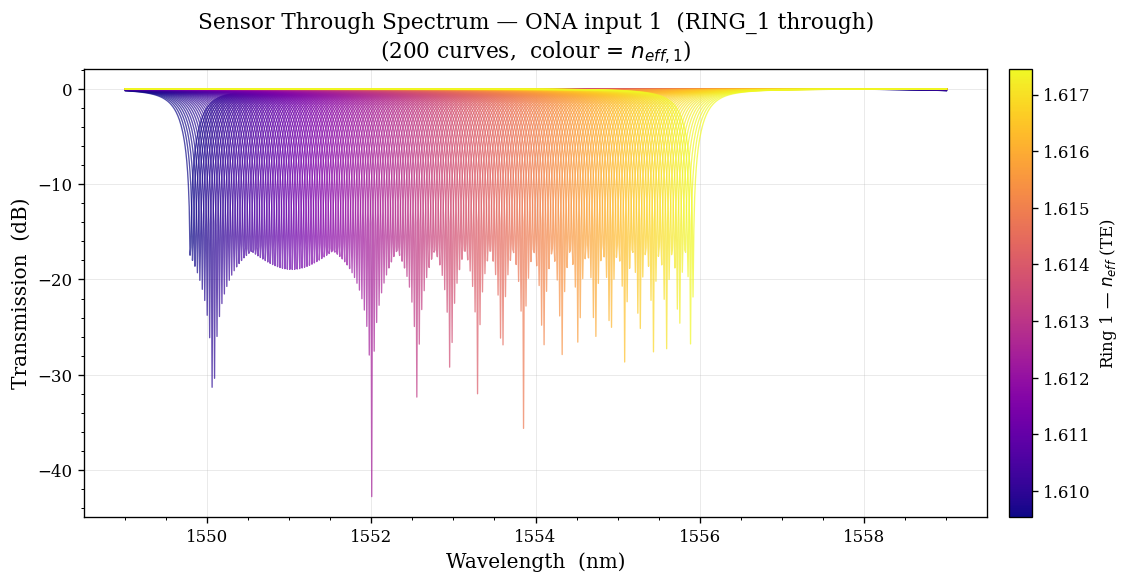

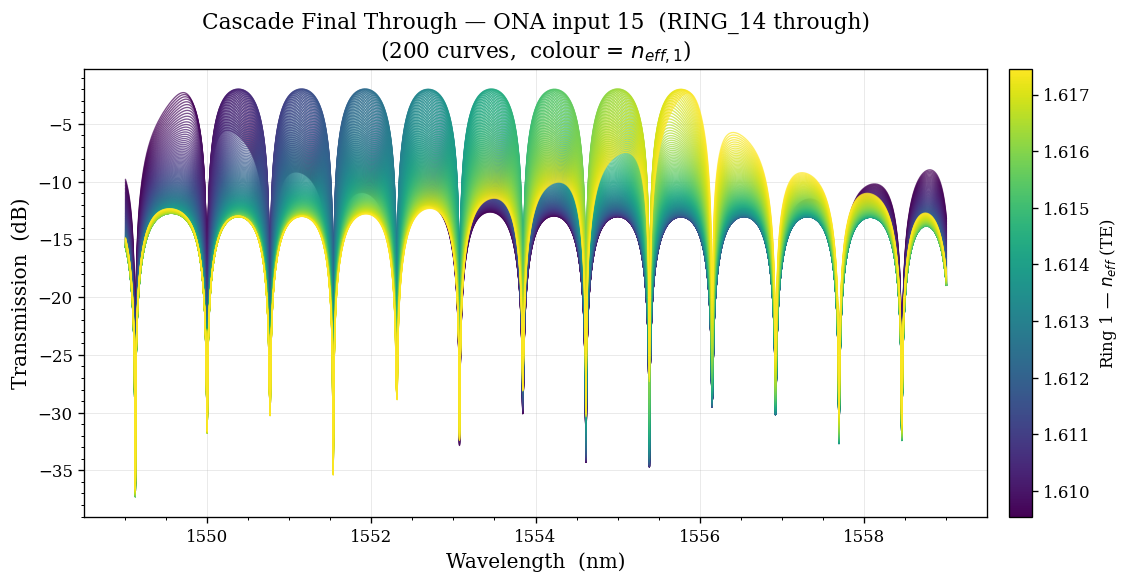

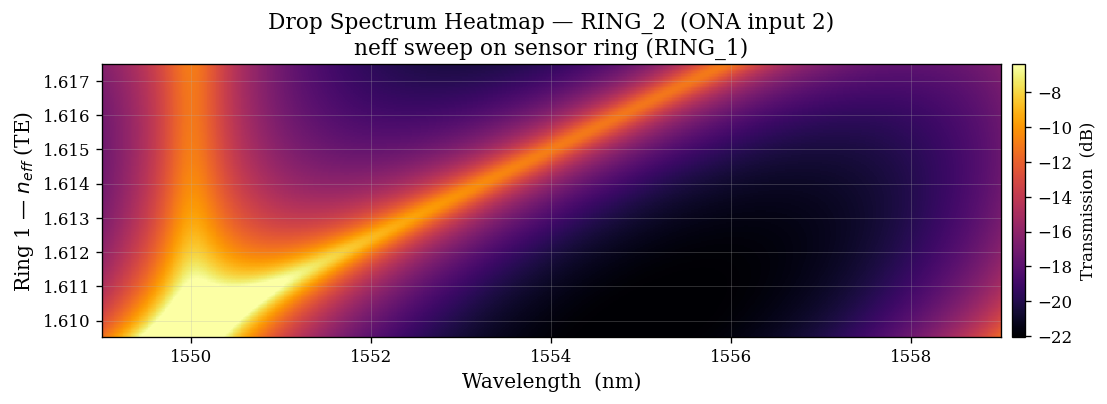

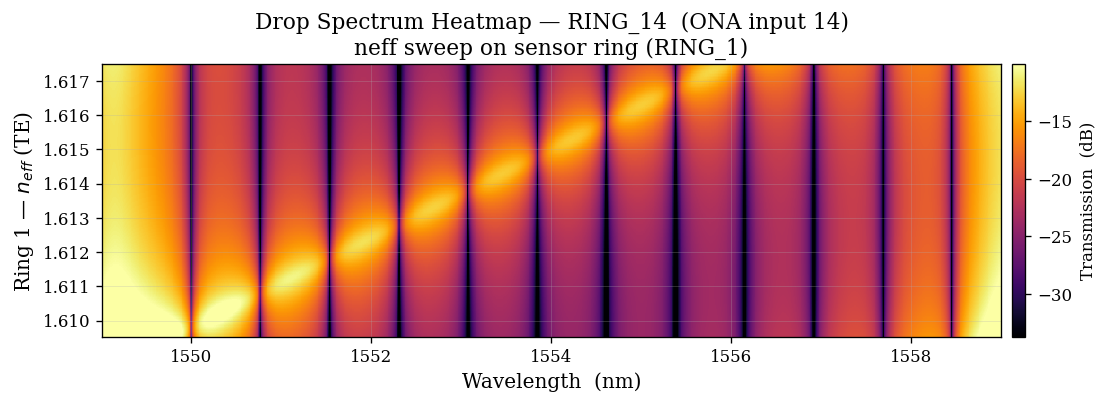

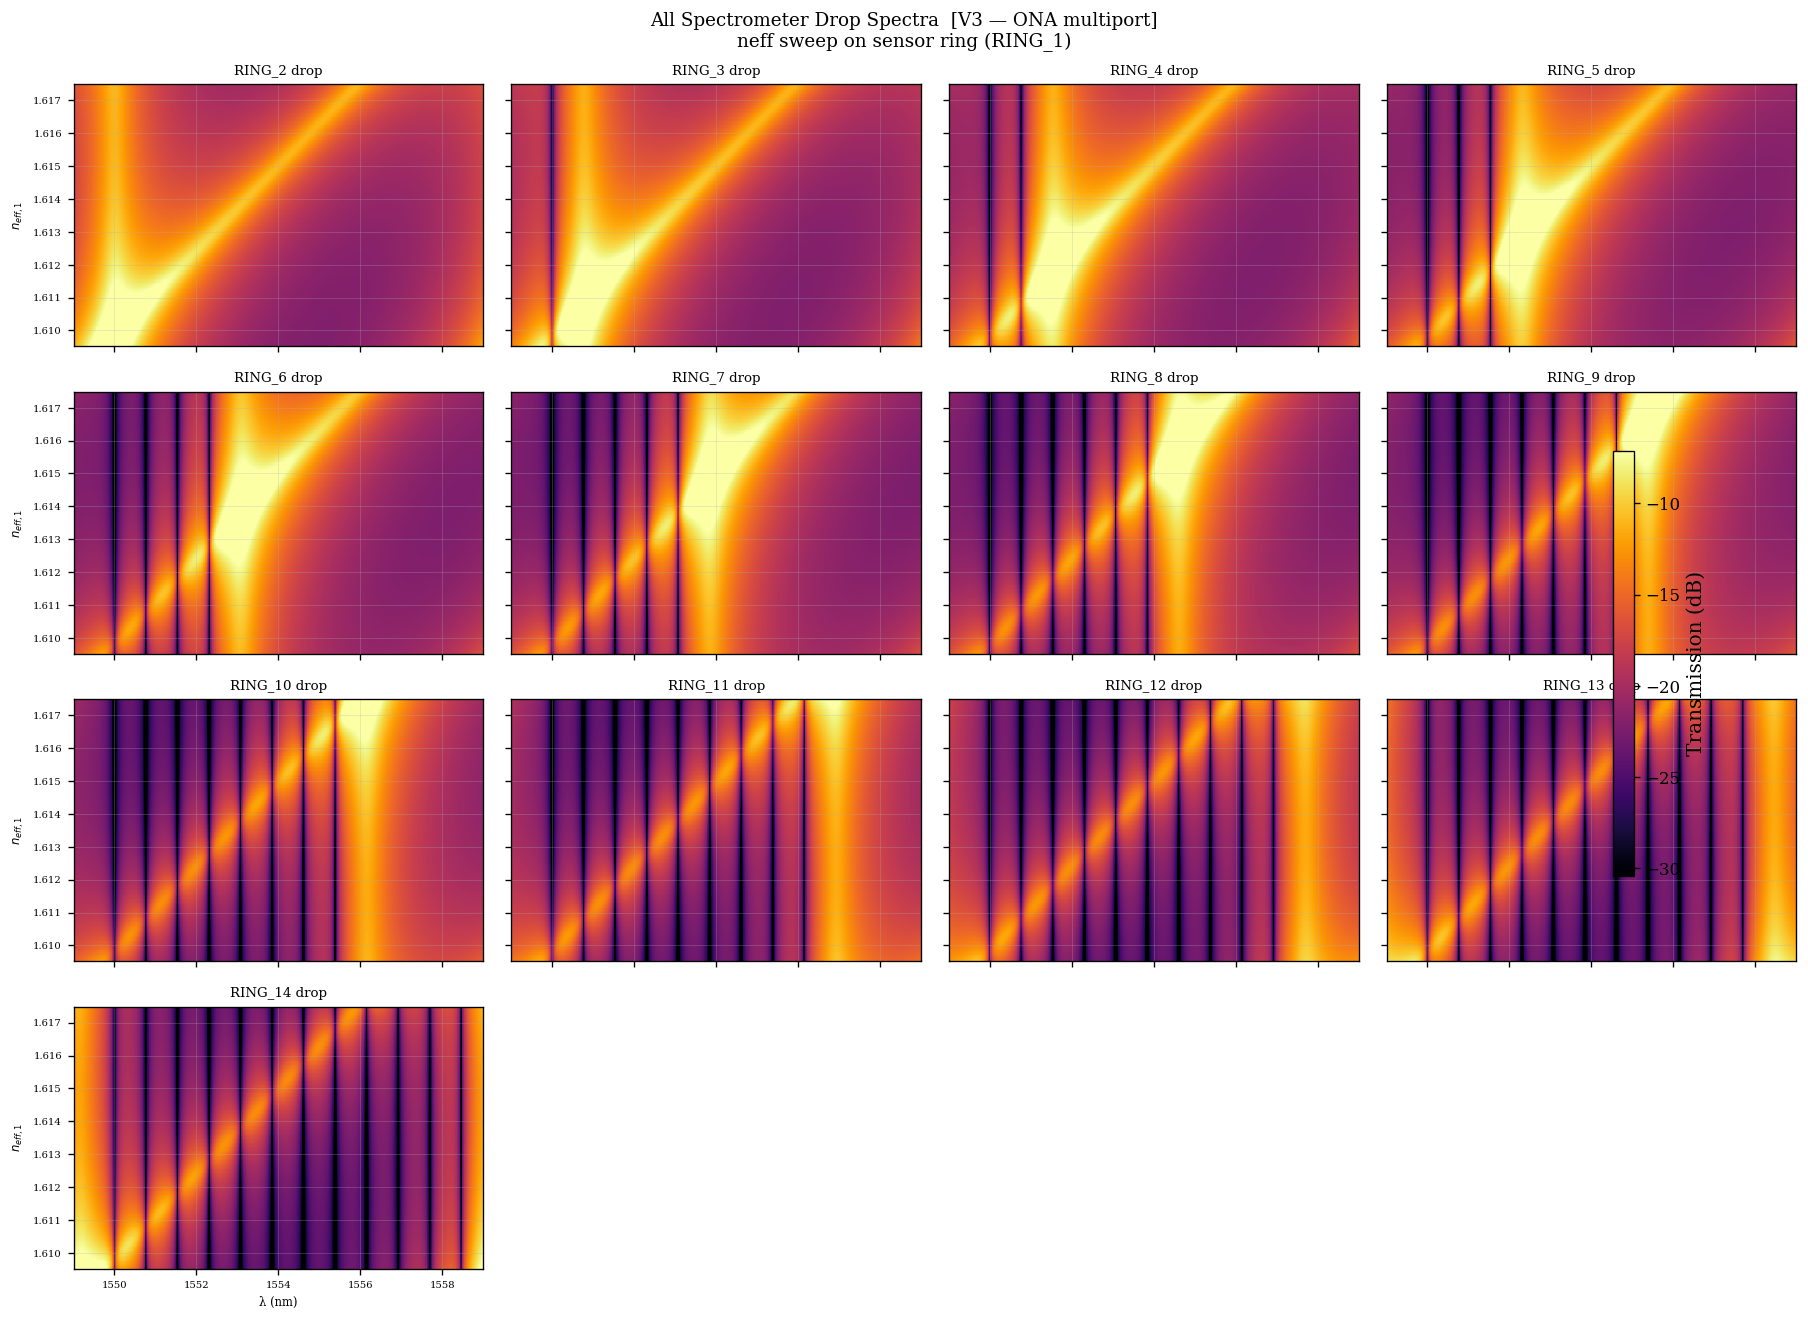

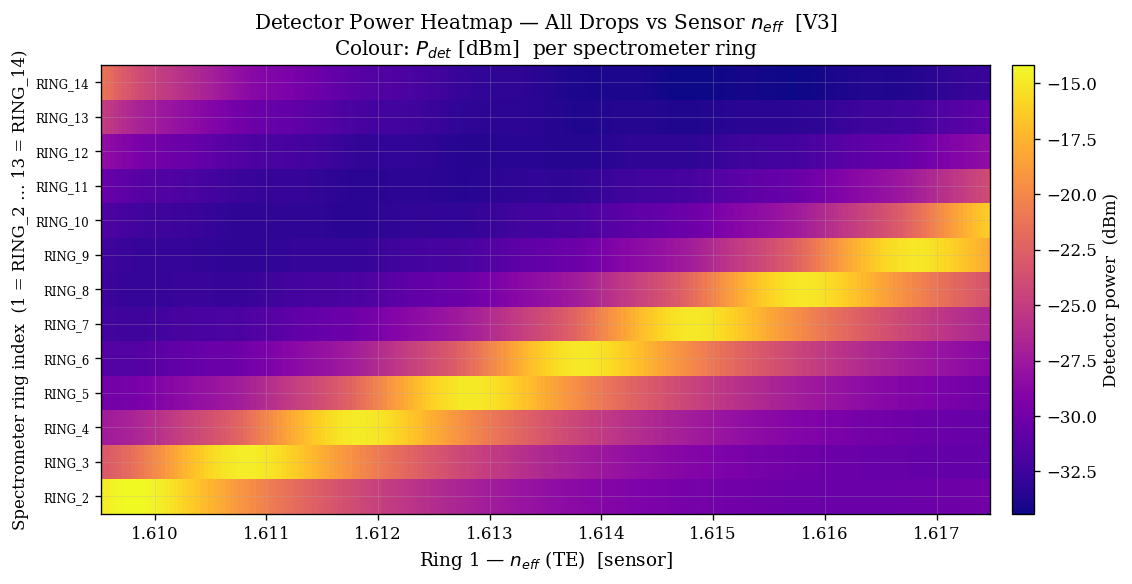

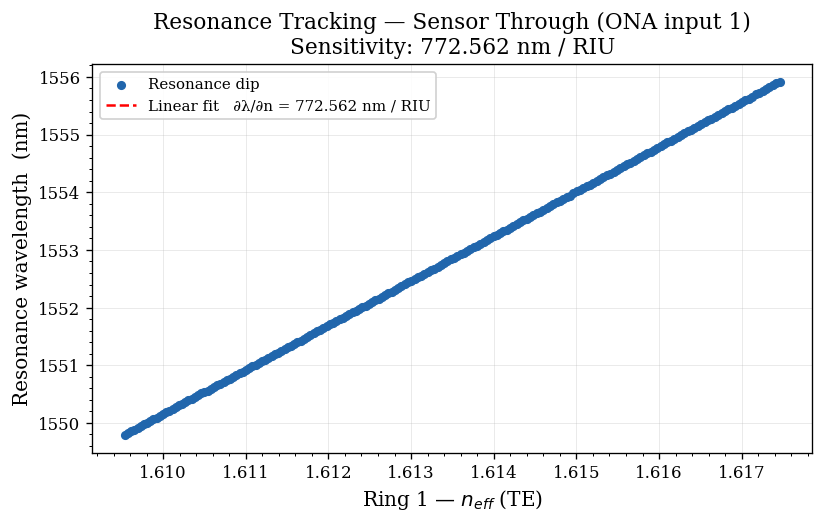


  Figures → C:\Users\jero0\OneDrive\Escritorio\Github\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_ICNT_cascade_ring_sweep\figures
  HDF5    → C:\Users\jero0\OneDrive\Escritorio\Github\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_ICNT_cascade_ring_sweep\ICNT_14Ring_Cascade_UniDir_neff_sweep_V3.h5


In [1]:
import math

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 1 — Imports · lumapi setup · Logging · I/O paths                     ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import sys, os, platform, time, logging
from pathlib import Path
from datetime import datetime
from typing import Optional, Tuple, Dict, Any

import numpy as np
import h5py
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

LUMERICAL_VERSION = "v202"
if platform.system() == "Windows":
    LUMERICAL_ROOT = rf"C:\Program Files\Lumerical\{LUMERICAL_VERSION}"
    LUMERICAL_API  = rf"{LUMERICAL_ROOT}\api\python"
    LUMERICAL_BIN  = rf"{LUMERICAL_ROOT}\bin"
else:
    LUMERICAL_ROOT = f"/opt/lumerical/{LUMERICAL_VERSION}"
    LUMERICAL_API  = f"{LUMERICAL_ROOT}/api/python"
    LUMERICAL_BIN  = f"{LUMERICAL_ROOT}/bin"

if "lumapi" in sys.modules:
    del sys.modules["lumapi"]
if LUMERICAL_API not in sys.path:
    sys.path.insert(0, LUMERICAL_API)
if platform.system() == "Windows":
    if hasattr(os, "add_dll_directory"):
        os.add_dll_directory(str(LUMERICAL_BIN))
    else:
        os.environ["PATH"] = str(LUMERICAL_BIN) + ";" + os.environ.get("PATH", "")

assert Path(LUMERICAL_API).exists(), f"API path not found: {LUMERICAL_API}"
assert Path(LUMERICAL_BIN).exists(), f"bin path not found: {LUMERICAL_BIN}"

import lumapi
print(f"lumapi imported from:\n  {lumapi.__file__}")

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s │ %(levelname)s │ %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger("ICNT_Cascade")

# ── V3: OPMs replaced by ONA multiport — version name updated ─────────────────
VERSION_NAME = "ICNT_14Ring_Cascade_UniDir_neff_sweep_V3"
PROJECT_DIR  = Path.cwd()
DATA_DIR     = PROJECT_DIR / "data_ICNT_cascade_ring_sweep"
DATA_DIR.mkdir(parents=True, exist_ok=True)
HDF5_PATH    = DATA_DIR / f"{VERSION_NAME}.h5"
FIGURES_DIR  = DATA_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n  Data directory : {DATA_DIR}")
print(f"  HDF5 output    : {HDF5_PATH}")
print(f"  Figures dir    : {FIGURES_DIR}")

# ═════════════════════════════════════════════════════════════════════════════
#  END CELL 1
# ═════════════════════════════════════════════════════════════════════════════


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 2 — Simulation parameters                                            ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

N_RINGS = 14

RING_RADIUS_M = np.array([
    19.0021e-6, 19.1818e-6, 19.1934e-6, 19.2051e-6,
    19.2168e-6, 19.2284e-6, 19.2401e-6, 19.2517e-6,
    19.4158e-6, 19.4275e-6, 19.4393e-6, 19.4511e-6,
    19.4628e-6, 19.4746e-6,
])
RING_LAMBDA_RES_M = np.array([
    1.5500000e-6, 1.5500000e-6, 1.5507692e-6, 1.5515385e-6,
    1.5523077e-6, 1.5530769e-6, 1.5538462e-6, 1.5546154e-6,
    1.5553846e-6, 1.5561538e-6, 1.5569231e-6, 1.5576923e-6,
    1.5584615e-6, 1.5582308e-6,
])
RING_NEFF_TE = np.array([
    1.609803, 1.633303, 1.633121, 1.632939,
    1.632758, 1.632576, 1.632394, 1.632213,
    1.631974, 1.631792, 1.631611, 1.631430,
    1.631248, 1.631067,
])
RING_NG_TE = np.array([
    2.020543, 1.991101, 1.990956, 1.990808,
    1.990659, 1.990509, 1.990356, 1.990203,
    1.990047, 1.989891, 1.989733, 1.989691,
    1.989528, 1.989364,
])
RING_D_TE_PS2_PER_KM = np.zeros(N_RINGS)
RING_D_TM_PS2_PER_KM = np.zeros(N_RINGS)
RING_NEFF_TM         = np.full(N_RINGS, 1.7000)
RING_NG_TM           = np.full(N_RINGS, 2.1000)
RING_KAPPA_INPUT_SQ  = np.array([
    0.145778, 0.145072, 0.145011, 0.144949,
    0.144888, 0.144827, 0.144765, 0.144704,
    0.145696, 0.145634, 0.145572, 0.145518,
    0.145456, 0.145394,
])
RING_KAPPA_DROP_SQ = np.array([
    0.143402, 0.142672, 0.142609, 0.142546,
    0.142484, 0.142420, 0.142357, 0.142294,
    0.143269, 0.143205, 0.143142, 0.143086,
    0.143022, 0.142958,
])
RING_LOSS_DB_PER_M = np.full(N_RINGS, 101.0)
RING_POLARIZATION  = ["TE"] * N_RINGS

ONA_LAMBDA_START_M = 1.549e-6
ONA_LAMBDA_STOP_M  = 1.559e-6
ONA_N_POINTS       = 1000
ONA_POWER_DBM      = 0.0

# ── V3 CHANGE: 15 ONA inputs ──────────────────────────────────────────────────
#   input  1 → RING_1  through   (sensor ring through port)
#   input  2 → RING_2  drop      (spectrometer ring 2 drop)
#   input  3 → RING_3  drop
#   ...
#   input 14 → RING_14 drop      (spectrometer ring 14 drop)
#   input 15 → RING_14 through   (final through port of cascade)
# ─────────────────────────────────────────────────────────────────────────────
ONA_N_INPUT_PORTS = 15   # was 2

# Number of spectrometer drops = rings 2..14
N_DROPS = 13   # replaces N_OPM; no physical OPM elements are used

SWEEP_N_POINTS = 200

SWEEP_NEFF = np.array([
    1.6095387512, 1.6095769971, 1.6096152579, 1.6096535338, 1.6096918246, 1.6097301304, 1.6097684512, 1.6098067871, 1.6098451380, 1.6098835039,
    1.6099218849, 1.6099602810, 1.6099986921, 1.6100371184, 1.6100755597, 1.6101140162, 1.6101524877, 1.6101909744, 1.6102294763, 1.6102679933,
    1.6103065255, 1.6103450728, 1.6103836354, 1.6104222131, 1.6104608060, 1.6104994142, 1.6105380376, 1.6105766762, 1.6106153301, 1.6106539993,
    1.6106926837, 1.6107313835, 1.6107700985, 1.6108088288, 1.6108475745, 1.6108863355, 1.6109251118, 1.6109639035, 1.6110027106, 1.6110415330,
    1.6110803708, 1.6111192240, 1.6111580927, 1.6111969767, 1.6112358762, 1.6112747912, 1.6113137215, 1.6113526674, 1.6113916287, 1.6114306056,
    1.6114695979, 1.6115086057, 1.6115476291, 1.6115866680, 1.6116257225, 1.6116647925, 1.6117038781, 1.6117429792, 1.6117820960, 1.6118212284,
    1.6118603763, 1.6118995400, 1.6119387192, 1.6119779141, 1.6120171247, 1.6120563509, 1.6120955929, 1.6121348505, 1.6121741238, 1.6122134129,
    1.6122527177, 1.6122920382, 1.6123313745, 1.6123707266, 1.6124100945, 1.6124494781, 1.6124888776, 1.6125282928, 1.6125677239, 1.6126071709,
    1.6126466336, 1.6126861123, 1.6127256068, 1.6127651172, 1.6128046436, 1.6128441858, 1.6128837439, 1.6129233180, 1.6129629081, 1.6130025141,
    1.6130421360, 1.6130817740, 1.6131214279, 1.6131610979, 1.6132007839, 1.6132404859, 1.6132802040, 1.6133199381, 1.6133596883, 1.6133994545,
    1.6134392369, 1.6134790354, 1.6135188500, 1.6135586807, 1.6135985276, 1.6136383906, 1.6136782698, 1.6137181652, 1.6137580767, 1.6137980045,
    1.6138379485, 1.6138779087, 1.6139178852, 1.6139578779, 1.6139978869, 1.6140379122, 1.6140779537, 1.6141180116, 1.6141580858, 1.6141981763,
    1.6142382832, 1.6142784064, 1.6143185460, 1.6143587019, 1.6143988743, 1.6144390631, 1.6144792683, 1.6145194899, 1.6145597279, 1.6145999825,
    1.6146402535, 1.6146805410, 1.6147208449, 1.6147611654, 1.6148015024, 1.6148418560, 1.6148822261, 1.6149226127, 1.6149630160, 1.6150034358,
    1.6150438722, 1.6150843252, 1.6151247949, 1.6151652812, 1.6152057842, 1.6152463038, 1.6152868401, 1.6153273931, 1.6153679628, 1.6154085492,
    1.6154491523, 1.6154897722, 1.6155304089, 1.6155710623, 1.6156117325, 1.6156524195, 1.6156931233, 1.6157338439, 1.6157745814, 1.6158153358,
    1.6158561070, 1.6158968950, 1.6159377000, 1.6159785219, 1.6160193607, 1.6160602164, 1.6161010891, 1.6161419787, 1.6161828853, 1.6162238089,
    1.6162647495, 1.6163057071, 1.6163466817, 1.6163876734, 1.6164286821, 1.6164697079, 1.6165107508, 1.6165518108, 1.6165928879, 1.6166339821,
    1.6166750935, 1.6167162220, 1.6167573676, 1.6167985305, 1.6168397106, 1.6168809078, 1.6169221223, 1.6169633540, 1.6170046030, 1.6170458692,
    1.6170871527, 1.6171284535, 1.6171697716, 1.6172111070, 1.6172524598, 1.6172938299, 1.6173352174, 1.6173766222, 1.6174180445, 1.6174594841,
])

SWEEP_NG = np.array([
    2.0218079294, 2.0217699008, 2.0217318512, 2.0216937805, 2.0216556887, 2.0216175759, 2.0215794420, 2.0215412869, 2.0215031108, 2.0214649135,
    2.0214266951, 2.0213884554, 2.0213501947, 2.0213119127, 2.0212736095, 2.0212352850, 2.0211969393, 2.0211585724, 2.0211201842, 2.0210817747,
    2.0210433438, 2.0210048917, 2.0209664182, 2.0209279233, 2.0208894071, 2.0208508695, 2.0208123105, 2.0207737300, 2.0207351281, 2.0206965047,
    2.0206578599, 2.0206191936, 2.0205805057, 2.0205417964, 2.0205030655, 2.0204643130, 2.0204255389, 2.0203867433, 2.0203479260, 2.0203090871,
    2.0202702265, 2.0202313443, 2.0201924404, 2.0201535147, 2.0201145674, 2.0200755983, 2.0200366074, 2.0199975948, 2.0199585603, 2.0199195041,
    2.0198804260, 2.0198413260, 2.0198022042, 2.0197630605, 2.0197238948, 2.0196847073, 2.0196454977, 2.0196062662, 2.0195670127, 2.0195277372,
    2.0194884397, 2.0194491201, 2.0194097784, 2.0193704147, 2.0193310288, 2.0192916208, 2.0192521906, 2.0192127383, 2.0191732638, 2.0191337670,
    2.0190942481, 2.0190547068, 2.0190151433, 2.0189755575, 2.0189359493, 2.0188963188, 2.0188566660, 2.0188169907, 2.0187772931, 2.0187375730,
    2.0186978305, 2.0186580655, 2.0186182780, 2.0185784679, 2.0185386354, 2.0184987803, 2.0184589025, 2.0184190022, 2.0183790793, 2.0183391337,
    2.0182991654, 2.0182591744, 2.0182191607, 2.0181791242, 2.0181390650, 2.0180989829, 2.0180588781, 2.0180187504, 2.0179785999, 2.0179384264,
    2.0178982301, 2.0178580108, 2.0178177685, 2.0177775033, 2.0177372150, 2.0176969037, 2.0176565693, 2.0176162119, 2.0175758313, 2.0175354277,
    2.0174950008, 2.0174545508, 2.0174140775, 2.0173735810, 2.0173330613, 2.0172925182, 2.0172519518, 2.0172113621, 2.0171707491, 2.0171301126,
    2.0170894527, 2.0170487694, 2.0170080626, 2.0169673322, 2.0169265784, 2.0168858010, 2.0168450000, 2.0168041754, 2.0167633272, 2.0167224553,
    2.0166815597, 2.0166406404, 2.0165996973, 2.0165587305, 2.0165177398, 2.0164767254, 2.0164356870, 2.0163946248, 2.0163535386, 2.0163124285,
    2.0162712945, 2.0162301364, 2.0161889542, 2.0161477481, 2.0161065178, 2.0160652634, 2.0160239848, 2.0159826820, 2.0159413551, 2.0159000039,
    2.0158586284, 2.0158172286, 2.0157758045, 2.0157343560, 2.0156928831, 2.0156513857, 2.0156098639, 2.0155683176, 2.0155267468, 2.0154851515,
    2.0154435315, 2.0154018869, 2.0153602177, 2.0153185238, 2.0152768051, 2.0152350618, 2.0151932936, 2.0151515006, 2.0151096828, 2.0150678401,
    2.0150259724, 2.0149840798, 2.0149421623, 2.0149002197, 2.0148582521, 2.0148162593, 2.0147742415, 2.0147321985, 2.0146901303, 2.0146480369,
    2.0146059182, 2.0145637743, 2.0145216050, 2.0144794103, 2.0144371902, 2.0143949447, 2.0143526738, 2.0143103773, 2.0142680552, 2.0142257076,
    2.0141833344, 2.0141409355, 2.0140985109, 2.0140560606, 2.0140135845, 2.0139710826, 2.0139285549, 2.0138860012, 2.0138434217, 2.0138008162,
])

# ── Validation ────────────────────────────────────────────────────────────────
for arr, name in [
    (RING_RADIUS_M,      "RING_RADIUS_M"),
    (RING_LAMBDA_RES_M,  "RING_LAMBDA_RES_M"),
    (RING_NEFF_TE,       "RING_NEFF_TE"),
    (RING_NG_TE,         "RING_NG_TE"),
    (RING_KAPPA_INPUT_SQ,"RING_KAPPA_INPUT_SQ"),
    (RING_KAPPA_DROP_SQ, "RING_KAPPA_DROP_SQ"),
    (RING_LOSS_DB_PER_M, "RING_LOSS_DB_PER_M"),
]:
    assert len(arr) == N_RINGS, f"{name} length mismatch"
assert len(SWEEP_NEFF) == SWEEP_N_POINTS
assert len(SWEEP_NG)   == SWEEP_N_POINTS

print("=" * 80)
print("  INTERCONNECT 14-Ring Cascade — Parameter Summary  [UNIDIRECTIONAL  V3]")
print("=" * 80)
print(f"  {'Ring':>5}  {'R [µm]':>9}  {'λ_res [nm]':>12}  "
      f"{'neff_TE':>9}  {'ng_TE':>8}  {'κ²_in':>8}  {'κ²_dr':>8}  {'Loss':>7}")
print("  " + "─" * 72)
for i in range(N_RINGS):
    tag = "  ← SENSOR (swept)" if i == 0 else ""
    print(f"  {i+1:>5}  {RING_RADIUS_M[i]*1e6:>9.4f}  "
          f"{RING_LAMBDA_RES_M[i]*1e9:>12.4f}  "
          f"{RING_NEFF_TE[i]:>9.6f}  {RING_NG_TE[i]:>8.6f}  "
          f"{RING_KAPPA_INPUT_SQ[i]:>8.6f}  {RING_KAPPA_DROP_SQ[i]:>8.6f}  "
          f"{RING_LOSS_DB_PER_M[i]:>7.1f}{tag}")
print()
print(f"  ONA   : λ {ONA_LAMBDA_START_M*1e9:.2f}–{ONA_LAMBDA_STOP_M*1e9:.2f} nm  "
      f"│  {ONA_N_POINTS} pts  │  {ONA_POWER_DBM} dBm  │  {ONA_N_INPUT_PORTS} input ports")
print(f"  Sweep : neff {SWEEP_NEFF[0]:.5f}→{SWEEP_NEFF[-1]:.5f}  "
      f"│  ng {SWEEP_NG[0]:.5f}→{SWEEP_NG[-1]:.5f}  │  {SWEEP_N_POINTS} pts")
print()
print("  CIRCUIT TOPOLOGY  [V3 — ONA multiport, no physical OPMs]")
print("  ─────────────────────────────────────────────────────────────────────")
print("  ONA  output    → RING_1  input")
print("  RING_1  out1   → ONA     input 1        (sensor through)")
print("  RING_1  out2   → RING_2  input           (sensor drop → cascade)")
print("  RING_n  out1   → RING_n+1 input  n=2..13 (through → next ring)")
print("  RING_n  out2   → ONA     input n  n=2..14 (drop → ONA input n)")
print("  RING_14 out1   → ONA     input 15        (final through)")
print("  ─────────────────────────────────────────────────────────────────────")
print("  ONA input mapping:")
print("    input  1 → RING_1  through  (sensor)")
for k in range(2, N_RINGS + 1):
    print(f"    input {k:>2} → RING_{k:<2} drop     (spectrometer {k-1:2d})")
print(f"    input 15 → RING_14 through  (cascade end)")
print("=" * 80)

# ═════════════════════════════════════════════════════════════════════════════
#  END CELL 2
# ═════════════════════════════════════════════════════════════════════════════


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 3 — Circuit builder + sweep engine + HDF5 storage  [V3]             ║
# ║                                                                            ║
# ║  KEY CHANGE vs V2                                                          ║
# ║  ─────────────────────────────────────────────────────────────────────     ║
# ║  The 13 physical OPM elements are REMOVED.  Instead, each spectrometer    ║
# ║  ring drop port is connected to a dedicated ONA input port (inputs 2-14). ║
# ║  The ONA then measures the full spectral transmission T(λ) at each drop.  ║
# ║                                                                            ║
# ║  The "detector power" that replicates laboratory conditions is computed    ║
# ║  in post-processing by integrating |T_drop(λ)|² over the ONA bandwidth:   ║
# ║                                                                            ║
# ║      P_det [W] = P_source [W] × ∫ |T_drop(λ)|² dλ / Δλ_ONA              ║
# ║                                                                            ║
# ║  This is physically identical to what a broadband photodetector does:      ║
# ║  it integrates all the spectral power that reaches it.  The result is a   ║
# ║  single power value per drop per sweep point → Power vs neff curve.       ║
# ║                                                                            ║
# ║  ONA PORT MAP (15 inputs)                                                  ║
# ║    input  1 → RING_1  output 1  (sensor through)                         ║
# ║    input  k → RING_k  output 2  k = 2..14  (spectrometer drops)          ║
# ║    input 15 → RING_14 output 1  (cascade end / final through)             ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

SPEED_OF_LIGHT = 299_792_458.0
ONA_NAME       = "ONA_1"

# ONA input port labels for easy reference
# drop_ona_input(k): ONA input number for RING_k drop  (k = 2..14)
def drop_ona_input(ring_k: int) -> int:
    """Return the ONA input port number (1-based) for RING_k drop.
    ring_k = 2..14  →  ONA input = ring_k  (i.e. 2..14)
    """
    assert 2 <= ring_k <= N_RINGS, f"ring_k must be 2..{N_RINGS}"
    return ring_k   # ONA input 2 = RING_2 drop, ..., input 14 = RING_14 drop

THROUGH_SENSOR_INPUT  = 1    # ONA input for RING_1 through
THROUGH_FINAL_INPUT   = 15   # ONA input for RING_14 through


def ring_name(ring_id: int) -> str:
    return f"RING_{ring_id}"


# ─────────────────────────────────────────────────────────────────────────────
# Scripting primitives (unchanged from V2)
# ─────────────────────────────────────────────────────────────────────────────
class ICScriptError(RuntimeError):
    pass


def _eval(ic, cmd: str) -> None:
    cmd = cmd.strip().rstrip(";") + ";"
    try:
        ic.eval(cmd)
    except Exception as exc:
        raise ICScriptError(
            f"\n  INTERCONNECT rejected:\n    {cmd}\n  Error: {exc}"
        ) from exc


def _try_eval(ic, cmd: str) -> bool:
    cmd = cmd.strip().rstrip(";") + ";"
    try:
        ic.eval(cmd)
        return True
    except Exception:
        return False


# ─────────────────────────────────────────────────────────────────────────────
# Ring parameter setter (unchanged from V2)
# ─────────────────────────────────────────────────────────────────────────────
def _apply_ring_params(ic, ring_idx: int,
                       neff_override: Optional[float] = None,
                       ng_override:   Optional[float] = None) -> None:
    name = ring_name(ring_idx + 1)
    neff = neff_override if neff_override is not None else float(RING_NEFF_TE[ring_idx])
    ng   = ng_override   if ng_override   is not None else float(RING_NG_TE[ring_idx])
    pol  = RING_POLARIZATION[ring_idx].upper()
    d_si = (float(RING_D_TE_PS2_PER_KM[ring_idx] if pol == "TE"
                  else RING_D_TM_PS2_PER_KM[ring_idx]) * 1e-15)
    res_hz        = SPEED_OF_LIGHT / float(RING_LAMBDA_RES_M[ring_idx])
    circumference = RING_RADIUS_M[ring_idx] * 2.0 * math.pi

    _eval(ic, f'setnamed("{name}", "length",                   {circumference:.12e})')
    _eval(ic, f'setnamed("{name}", "frequency",                {res_hz:.12e})')
    _eval(ic, f'setnamed("{name}", "effective index 1",        {neff:.12f})')
    _eval(ic, f'setnamed("{name}", "group index 1",            {ng:.12f})')
    _eval(ic, f'setnamed("{name}", "loss 1",                   {RING_LOSS_DB_PER_M[ring_idx]:.6f})')
    _eval(ic, f'setnamed("{name}", "dispersion 1",             {d_si:.12e})')
    _eval(ic, f'setnamed("{name}", "coupling coefficient 1 1", {RING_KAPPA_INPUT_SQ[ring_idx]:.12f})')
    _eval(ic, f'setnamed("{name}", "coupling coefficient 1 2", {RING_KAPPA_DROP_SQ[ring_idx]:.12f})')
    _eval(ic, f'setnamed("{name}", "configuration", "unidirectional")')


# ─────────────────────────────────────────────────────────────────────────────
# Sensor ring updater (unchanged from V2 — only RING_1 changes in sweep)
# ─────────────────────────────────────────────────────────────────────────────
def _update_ring1_neff_ng(ic, neff: float, ng: float) -> None:
    name = ring_name(1)
    _eval(ic, f'setnamed("{name}", "effective index 1", {neff:.12f})')
    _eval(ic, f'setnamed("{name}", "group index 1",     {ng:.12f})')


# ─────────────────────────────────────────────────────────────────────────────
# Circuit builder — V3 TOPOLOGY (ONA multiport, no OPMs)
# ─────────────────────────────────────────────────────────────────────────────
def _build_circuit(ic) -> None:
    """
    Build the 14-ring cascade with ONA multiport measurement.

    V3 TOPOLOGY
    ────────────────────────────────────────────────────────────────
    ONA  output    → RING_1  input

    RING_1  out1   → ONA  input 1          (sensor through)
    RING_1  out2   → RING_2 input           (sensor drop → cascade)

    For n = 2..13:
      RING_n  out1 → RING_{n+1} input       (through → next ring)
      RING_n  out2 → ONA  input n            (drop → ONA input n)

    RING_14 out1   → ONA  input 15          (final through)
    RING_14 out2   → ONA  input 14          (RING_14 drop → ONA input 14)

    ONA input mapping:
      input  1 = RING_1  through  (sensor)
      input  k = RING_k  drop     k = 2..14
      input 15 = RING_14 through  (cascade end)
    """
    _eval(ic, "switchtodesign")
    _try_eval(ic, "selectall")
    _try_eval(ic, "delete")

    pwr_W   = 10.0 ** (ONA_POWER_DBM / 10.0) * 1e-3
    f_start = SPEED_OF_LIGHT / ONA_LAMBDA_STOP_M
    f_stop  = SPEED_OF_LIGHT / ONA_LAMBDA_START_M

    # ── ONA — 15 input ports ──────────────────────────────────────────────────
    _eval(ic, 'addelement("Optical Network Analyzer")')
    _eval(ic, f'set("name", "{ONA_NAME}")')
    _try_eval(ic, 'set("x position", 0)')
    _try_eval(ic, 'set("y position", 0)')
    _eval(ic, f'setnamed("{ONA_NAME}", "input parameter",       "start and stop")')
    _eval(ic, f'setnamed("{ONA_NAME}", "number of input ports", {int(ONA_N_INPUT_PORTS)})')
    _eval(ic, f'setnamed("{ONA_NAME}", "start frequency",       {f_start:.12e})')
    _eval(ic, f'setnamed("{ONA_NAME}", "stop frequency",        {f_stop:.12e})')
    _eval(ic, f'setnamed("{ONA_NAME}", "number of points",      {int(ONA_N_POINTS)})')
    _eval(ic, f'setnamed("{ONA_NAME}", "power",                 {pwr_W:.12e})')
    log.info(f"  {ONA_NAME} added — {ONA_N_INPUT_PORTS} input ports configured.")

    # ── Rings ─────────────────────────────────────────────────────────────────
    for i in range(N_RINGS):
        rn = ring_name(i + 1)
        _eval(ic, 'addelement("Double Bus Ring Resonator")')
        _eval(ic, f'set("name", "{rn}")')
        _try_eval(ic, f'set("x position", {float((i + 1) * 220)})')
        _try_eval(ic, f'set("y position", 0)')
        _apply_ring_params(ic, ring_idx=i)
        log.info(
            f"  RING_{i+1:2d} added  "
            f"[unidir, neff={RING_NEFF_TE[i]:.6f}, "
            f"L={RING_RADIUS_M[i]*2*math.pi*1e6:.4f} µm]"
        )

    # ── NO OPM elements — drops go directly to ONA inputs ────────────────────

    # ── Connections ───────────────────────────────────────────────────────────
    def wire(elem_a: str, port_a: str, elem_b: str, port_b: str) -> None:
        _eval(ic, f'connect("{elem_a}", "{port_a}", "{elem_b}", "{port_b}")')

    # ONA output → RING_1 input
    wire(ONA_NAME, "output", ring_name(1), "input")

    # RING_1 through → ONA input 1  (sensor through)
    wire(ring_name(1), "output 1", ONA_NAME, f"input {THROUGH_SENSOR_INPUT}")

    # RING_1 drop → RING_2 input  (cascade entry)
    wire(ring_name(1), "output 2", ring_name(2), "input")

    # RING_2 .. RING_13: through → next ring,  drop → ONA input n
    for i in range(2, N_RINGS):      # i = 2, 3, ..., 13
        wire(ring_name(i), "output 1", ring_name(i + 1), "input")
        wire(ring_name(i), "output 2", ONA_NAME, f"input {drop_ona_input(i)}")
        log.info(f"  RING_{i} drop → ONA input {drop_ona_input(i)}")

    # RING_14 drop → ONA input 14
    wire(ring_name(N_RINGS), "output 2", ONA_NAME, f"input {drop_ona_input(N_RINGS)}")
    log.info(f"  RING_14 drop → ONA input {drop_ona_input(N_RINGS)}")

    # RING_14 through → ONA input 15  (final through)
    wire(ring_name(N_RINGS), "output 1", ONA_NAME, f"input {THROUGH_FINAL_INPUT}")
    log.info(f"  RING_14 through → ONA input {THROUGH_FINAL_INPUT}")

    log.info(
        f"V3 circuit built: {N_RINGS} rings, {N_DROPS} drop ports → ONA inputs 2-14, "
        f"no OPM elements."
    )


# ─────────────────────────────────────────────────────────────────────────────
# Result extraction — V3
# ─────────────────────────────────────────────────────────────────────────────
def _extract_results(ic) -> tuple:
    """
    Extract all ONA transmission spectra after run().

    ONA PORT MAP (V3)
    ─────────────────
    input  1 → RING_1  through   → T_sensor_through_dB   (n_wl,)
    input  k → RING_k  drop      → T_drop_dB[k-2, :]     k=2..14  (13, n_wl)
    input 15 → RING_14 through   → T_final_through_dB    (n_wl,)

    INTEGRATED DETECTOR POWER
    ─────────────────────────
    For each drop port k (ring 2..14):

        P_det[k] [W] = P_source [W] × mean(|T_drop_k(λ)|²)

    where mean is taken over the full ONA wavelength band.
    This replicates a broadband photodetector integrating all arriving power.
    The result is reported in dBm.

    Returns
    -------
    wl_m                  : (n_wl,)       wavelengths [m], ascending
    T_sensor_through_dB   : (n_wl,)       RING_1 through spectrum [dB]
    T_final_through_dB    : (n_wl,)       RING_14 through spectrum [dB]
    T_drop_dB             : (N_DROPS, n_wl)  drop spectra for rings 2..14 [dB]
    drop_power_dBm        : (N_DROPS,)    integrated detector power per drop [dBm]
    """
    # ── Frequency / wavelength axis from ONA input 1 ─────────────────────────
    raw_ref = ic.getresult(ONA_NAME, f"input {THROUGH_SENSOR_INPUT}/mode 1/transmission")
    f_arr   = np.asarray(raw_ref["frequency"]).flatten()
    sort_i  = np.argsort(f_arr)[::-1]          # descending f → ascending λ
    wl_m    = SPEED_OF_LIGHT / f_arr[sort_i]
    n_wl    = len(wl_m)

    # Source power in Watts (needed for absolute power calculation)
    p_source_W = 10.0 ** (ONA_POWER_DBM / 10.0) * 1e-3

    # ── Helper: read one ONA input, return T [linear] sorted ascending in λ ──
    def _read_T_linear(port_label: str) -> np.ndarray:
        raw = ic.getresult(ONA_NAME, f"{port_label}/mode 1/transmission")
        T   = np.asarray(raw["TE transmission"]).flatten()[sort_i]
        return np.abs(T)

    def _T_to_dB(T_lin: np.ndarray) -> np.ndarray:
        return 10.0 * np.log10(np.where(T_lin > 0, T_lin, 1e-30))

    # ── ONA input 1: sensor through ───────────────────────────────────────────
    T_sensor_lin        = _read_T_linear(f"input {THROUGH_SENSOR_INPUT}")
    T_sensor_through_dB = _T_to_dB(T_sensor_lin)

    # ── ONA input 15: cascade final through ───────────────────────────────────
    T_final_lin          = _read_T_linear(f"input {THROUGH_FINAL_INPUT}")
    T_final_through_dB   = _T_to_dB(T_final_lin)

    # ── ONA inputs 2..14: spectrometer drops ─────────────────────────────────
    T_drop_dB      = np.full((N_DROPS, n_wl), np.nan)
    drop_power_dBm = np.full(N_DROPS, np.nan)

    for k in range(2, N_RINGS + 1):          # k = 2..14
        drop_idx = k - 2                      # 0-based index into N_DROPS arrays
        ona_port = drop_ona_input(k)          # ONA input number (= k)
        try:
            T_lin = _read_T_linear(f"input {ona_port}")
            T_drop_dB[drop_idx, :] = _T_to_dB(T_lin)

            # ── Integrated detector power ─────────────────────────────────────
            # mean(|T|²) over the ONA band = fraction of source power reaching
            # the detector.  For a broadband (incoherent) flat-spectrum source
            # this is the physical power seen by a wideband photodetector.
            # |T|² is already the power transmittance (ONA returns amplitude
            # transmission, so |T_lin|² is the power ratio).
            mean_T_sq  = float(np.mean(T_lin ** 2))
            p_det_W    = p_source_W * mean_T_sq
            drop_power_dBm[drop_idx] = 10.0 * np.log10(max(p_det_W, 1e-40) * 1e3)

        except Exception as exc:
            log.warning(f"  Drop extraction failed RING_{k} (ONA input {ona_port}): {exc}")

    return wl_m, T_sensor_through_dB, T_final_through_dB, T_drop_dB, drop_power_dBm


# ─────────────────────────────────────────────────────────────────────────────
# HDF5 initialisation — V3 dataset names
# ─────────────────────────────────────────────────────────────────────────────
def _init_hdf5(wl_ref_m: np.ndarray) -> None:
    n_pts = SWEEP_N_POINTS
    n_wl  = len(wl_ref_m)
    with h5py.File(HDF5_PATH, "w") as f:
        md = f.create_group("metadata")
        md.create_dataset("neff_sweep",    data=SWEEP_NEFF)
        md.create_dataset("ng_sweep",      data=SWEEP_NG)
        md.create_dataset("wavelengths_m", data=wl_ref_m)
        md.attrs["version_name"]          = VERSION_NAME
        md.attrs["n_rings"]               = N_RINGS
        md.attrs["n_drops"]               = N_DROPS
        md.attrs["drop_layout"]           = "drop_k monitors RING_(k+2), k=0..12 (0-based)"
        md.attrs["sweep_n_points"]        = SWEEP_N_POINTS
        md.attrs["ring_model"]            = "Double Bus Ring Resonator"
        md.attrs["ring_configuration"]    = "unidirectional"
        md.attrs["topology"]              = (
            "V3: ONA multiport, no OPMs. "
            "ONA input 1=RING_1 through, input k=RING_k drop (k=2-14), "
            "input 15=RING_14 through"
        )
        md.attrs["ona_lambda_start_m"]    = ONA_LAMBDA_START_M
        md.attrs["ona_lambda_stop_m"]     = ONA_LAMBDA_STOP_M
        md.attrs["ona_n_points"]          = ONA_N_POINTS
        md.attrs["ona_power_dBm"]         = ONA_POWER_DBM
        md.attrs["ona_n_input_ports"]     = ONA_N_INPUT_PORTS
        md.attrs["power_calc_method"]     = (
            "P_det[W] = P_source[W] * mean(|T_drop(lambda)|^2) over ONA band"
        )
        md.attrs["timestamp_start"]       = datetime.now().isoformat()

        for i in range(N_RINGS):
            p = f"ring{i+1}_"
            md.attrs[p + "radius_m"]        = RING_RADIUS_M[i]
            md.attrs[p + "circumference_m"] = RING_RADIUS_M[i] * 2.0 * math.pi
            md.attrs[p + "lambda_res_m"]    = RING_LAMBDA_RES_M[i]
            md.attrs[p + "neff_TE"]         = RING_NEFF_TE[i]
            md.attrs[p + "ng_TE"]           = RING_NG_TE[i]
            md.attrs[p + "kappa_input_sq"]  = RING_KAPPA_INPUT_SQ[i]
            md.attrs[p + "kappa_drop_sq"]   = RING_KAPPA_DROP_SQ[i]
            md.attrs[p + "loss_dB_per_m"]   = RING_LOSS_DB_PER_M[i]

        for k in range(2, N_RINGS + 1):
            md.attrs[f"drop{k-1}_ring"]    = f"RING_{k} output 2 (drop) → ONA input {k}"

        rg = f.create_group("results")
        # Sensor through and final through spectra
        rg.create_dataset("T_sensor_through_dB",
                          data=np.full((n_pts, n_wl), np.nan), chunks=(1, n_wl))
        rg.create_dataset("T_final_through_dB",
                          data=np.full((n_pts, n_wl), np.nan), chunks=(1, n_wl))
        # Drop spectra: (sweep_pts, N_DROPS, n_wl)
        rg.create_dataset("T_drop_dB",
                          data=np.full((n_pts, N_DROPS, n_wl), np.nan),
                          chunks=(1, 1, n_wl))
        # Integrated detector power per drop: (sweep_pts, N_DROPS)
        rg.create_dataset("drop_power_dBm",
                          data=np.full((n_pts, N_DROPS), np.nan),
                          chunks=(1, N_DROPS))

        f.create_group("flags").create_dataset(
            "computed", data=np.zeros(n_pts, dtype=bool), chunks=(1,))

    log.info(f"HDF5 V3 initialised ({N_DROPS} drops, {n_wl} wavelengths) → {HDF5_PATH}")


# ─────────────────────────────────────────────────────────────────────────────
# Main sweep
# ─────────────────────────────────────────────────────────────────────────────
def run_interconnect_sweep(hide_gui: bool = False) -> Dict[str, Any]:
    n_pts = SWEEP_N_POINTS
    wavelengths_m         = None
    T_sensor_through_dB   = None
    T_final_through_dB    = None
    T_drop_dB             = None
    drop_power_dBm        = None
    computed   = np.zeros(n_pts, dtype=bool)
    hdf5_ready = False

    # ── Resume from cache ─────────────────────────────────────────────────────
    if HDF5_PATH.exists():
        log.info(f"Cache found → {HDF5_PATH}")
        try:
            with h5py.File(HDF5_PATH, "r") as f:
                wavelengths_m       = f["metadata/wavelengths_m"][:]
                T_sensor_through_dB = f["results/T_sensor_through_dB"][:]
                T_final_through_dB  = f["results/T_final_through_dB"][:]
                T_drop_dB           = f["results/T_drop_dB"][:]
                drop_power_dBm      = f["results/drop_power_dBm"][:]
                computed[:]         = f["flags/computed"][:]
            hdf5_ready = True
            n_cached   = int(computed.sum())
            log.info(f"Cached: {n_cached}/{n_pts}  |  Remaining: {n_pts - n_cached}")
            if n_pts - n_cached == 0:
                log.info("All sweep points cached — skipping INTERCONNECT launch.")
                return _pack_results(wavelengths_m, T_sensor_through_dB,
                                     T_final_through_dB, T_drop_dB,
                                     drop_power_dBm, computed)
        except Exception as exc:
            log.warning(f"Cache unreadable ({exc}). Starting fresh.")
            wavelengths_m = T_sensor_through_dB = T_final_through_dB = None
            T_drop_dB = drop_power_dBm = None
            computed[:] = False
            hdf5_ready  = False
    else:
        log.info("No cache — starting fresh sweep.")

    log.info("Launching INTERCONNECT …")
    ic         = lumapi.INTERCONNECT(hide=hide_gui)
    runs_done  = 0
    runs_total = int((~computed).sum())
    t_start    = time.time()

    try:
        _build_circuit(ic)
        log.info(f"Circuit ready — {runs_total} sweep points to compute …")

        for s_idx in range(n_pts):
            if computed[s_idx]:
                continue

            neff_val = float(SWEEP_NEFF[s_idx])
            ng_val   = float(SWEEP_NG[s_idx])

            _eval(ic, "switchtodesign")
            _update_ring1_neff_ng(ic, neff_val, ng_val)

            # ── Run ───────────────────────────────────────────────────────────
            try:
                _eval(ic, "run")
            except ICScriptError as exc:
                log.warning(
                    f"  RUN FAILED  pt={s_idx:3d}  "
                    f"neff={neff_val:.6f}  ng={ng_val:.6f}  →  {exc}"
                )
                computed[s_idx] = True
                if hdf5_ready:
                    with h5py.File(HDF5_PATH, "r+") as hf:
                        hf["flags/computed"][s_idx] = True
                        hf.flush()
                continue

            # ── Extract ───────────────────────────────────────────────────────
            try:
                wl_m, t_sen, t_fin, t_drop, p_drop = _extract_results(ic)
            except Exception as exc:
                log.warning(f"  EXTRACT FAILED  pt={s_idx:3d}: {exc}")
                computed[s_idx] = True
                continue

            # ── Initialise arrays on first valid point ────────────────────────
            if wavelengths_m is None:
                n_wl                = len(wl_m)
                wavelengths_m       = wl_m
                T_sensor_through_dB = np.full((n_pts, n_wl),          np.nan)
                T_final_through_dB  = np.full((n_pts, n_wl),          np.nan)
                T_drop_dB           = np.full((n_pts, N_DROPS, n_wl), np.nan)
                drop_power_dBm      = np.full((n_pts, N_DROPS),        np.nan)
                if not hdf5_ready:
                    _init_hdf5(wl_m)
                    hdf5_ready = True

            # ── Store in memory ───────────────────────────────────────────────
            T_sensor_through_dB[s_idx, :]    = t_sen
            T_final_through_dB [s_idx, :]    = t_fin
            T_drop_dB          [s_idx, :, :] = t_drop
            drop_power_dBm     [s_idx, :]    = p_drop
            computed           [s_idx]        = True

            # ── Flush to HDF5 ─────────────────────────────────────────────────
            with h5py.File(HDF5_PATH, "r+") as hf:
                hf["results/T_sensor_through_dB"][s_idx, :]    = t_sen
                hf["results/T_final_through_dB"] [s_idx, :]    = t_fin
                hf["results/T_drop_dB"]          [s_idx, :, :] = t_drop
                hf["results/drop_power_dBm"]     [s_idx, :]    = p_drop
                hf["flags/computed"]             [s_idx]        = True
                hf.flush()

            runs_done += 1
            if runs_done % 5 == 0 or runs_done == runs_total:
                elapsed = time.time() - t_start
                rate    = runs_done / elapsed if elapsed > 0 else 1e-9
                eta     = (runs_total - runs_done) / rate
                log.info(
                    f"  [{runs_done:3d}/{runs_total}]  "
                    f"neff={neff_val:.6f}  ng={ng_val:.6f}  │  "
                    f"{rate:.2f} sim/s  │  ETA {eta:5.0f} s"
                )

        if hdf5_ready:
            with h5py.File(HDF5_PATH, "r+") as hf:
                hf["metadata"].attrs["timestamp_end"]  = datetime.now().isoformat()
                hf["metadata"].attrs["runs_completed"] = int(computed.sum())

    finally:
        try:
            ic.close()
        except Exception:
            pass
        log.info("INTERCONNECT session closed.")

    elapsed = time.time() - t_start
    log.info(
        f"Sweep done │ {runs_done} new runs │ "
        f"total={elapsed:.1f} s │ avg={elapsed/max(runs_done, 1):.2f} s/sim"
    )
    return _pack_results(wavelengths_m, T_sensor_through_dB,
                         T_final_through_dB, T_drop_dB, drop_power_dBm, computed)


def _pack_results(wl, t_sen, t_fin, t_drop, p_drop, comp) -> Dict[str, Any]:
    return dict(
        neff_sweep            = SWEEP_NEFF,
        ng_sweep              = SWEEP_NG,
        wavelengths_m         = wl,
        T_sensor_through_dB   = t_sen,
        T_final_through_dB    = t_fin,
        T_drop_dB             = t_drop,
        drop_power_dBm        = p_drop,
        computed              = comp,
    )


# ── Execute sweep ──────────────────────────────────────────────────────────────
sweep_results = run_interconnect_sweep(hide_gui=False)

neff_sweep          = sweep_results["neff_sweep"]
ng_sweep            = sweep_results["ng_sweep"]
wavelengths_m       = sweep_results["wavelengths_m"]
T_sensor_through_dB = sweep_results["T_sensor_through_dB"]
T_final_through_dB  = sweep_results["T_final_through_dB"]
T_drop_dB           = sweep_results["T_drop_dB"]
drop_power_dBm      = sweep_results["drop_power_dBm"]
computed            = sweep_results["computed"]
wavelengths_nm      = wavelengths_m * 1e9 if wavelengths_m is not None else None

print(f"\n  Sweep complete — {computed.sum()} / {len(computed)} pts computed")
if wavelengths_m is not None:
    print(f"  T_sensor_through_dB  shape : {T_sensor_through_dB.shape}")
    print(f"  T_final_through_dB   shape : {T_final_through_dB.shape}")
    print(f"  T_drop_dB            shape : {T_drop_dB.shape}   (RING_2..14 drops)")
    print(f"  drop_power_dBm       shape : {drop_power_dBm.shape}")
print(f"  HDF5                        : {HDF5_PATH}")

# ═════════════════════════════════════════════════════════════════════════════
#  END CELL 3
# ═════════════════════════════════════════════════════════════════════════════


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 4 — Post-processing · Visualisation  [V3]                            ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

plt.rcParams.update({
    "font.family"    : "serif",
    "font.serif"     : ["DejaVu Serif", "Georgia", "Times New Roman"],
    "font.size"      : 11, "axes.labelsize": 12, "axes.titlesize": 13,
    "legend.fontsize": 9,  "xtick.labelsize": 10, "ytick.labelsize": 10,
    "axes.linewidth" : 0.8, "axes.grid": True, "grid.alpha": 0.3,
    "grid.linewidth" : 0.5, "lines.linewidth": 1.4,
    "figure.dpi"     : 120, "savefig.dpi": 300, "savefig.bbox": "tight",
})

# ── Spectrometer ring labels (drop index 0-based → RING 2..14) ───────────────
DROP_LABELS = [f"RING_{k+2}" for k in range(N_DROPS)]   # RING_2 .. RING_14


# ─────────────────────────────────────────────────────────────────────────────
# Data loader helpers
# ─────────────────────────────────────────────────────────────────────────────
def load_results(path: Path = HDF5_PATH) -> Optional[Dict[str, Any]]:
    if not path.exists():
        return None
    try:
        with h5py.File(path, "r") as f:
            if "metadata/wavelengths_m" not in f:
                return None
            wl = f["metadata/wavelengths_m"][:]
            if wl is None or len(wl) == 0:
                return None
            return dict(
                neff_sweep            = f["metadata/neff_sweep"][:],
                ng_sweep              = f["metadata/ng_sweep"][:],
                wavelengths_m         = wl,
                T_sensor_through_dB   = f["results/T_sensor_through_dB"][:],
                T_final_through_dB    = f["results/T_final_through_dB"][:],
                T_drop_dB             = f["results/T_drop_dB"][:],
                drop_power_dBm        = f["results/drop_power_dBm"][:],
                computed              = f["flags/computed"][:],
            )
    except Exception as exc:
        log.warning(f"Could not read HDF5 ({exc}): {path}")
        return None


def get_results(path: Path = HDF5_PATH) -> Dict[str, Any]:
    mem_reason = ""
    try:
        r  = sweep_results
        wl = r.get("wavelengths_m")
        if wl is not None and len(wl) > 0:
            return r
        mem_reason = "sweep_results in memory but wavelengths_m is None"
    except NameError:
        mem_reason = "sweep_results not defined (Cell 3 not run)"
    r_hdf5 = load_results(path)
    if r_hdf5 is not None:
        log.info(f"Loaded from HDF5: {int(r_hdf5['computed'].sum())}/{SWEEP_N_POINTS} pts.")
        return r_hdf5
    hdf5_reason = (
        f"HDF5 exists but empty — delete and re-run Cell 3:\n    {path}"
        if path.exists() else f"HDF5 not found:\n    {path}"
    )
    raise RuntimeError(
        f"\n{'='*65}\n  No results available.\n"
        f"  Memory : {mem_reason}\n  HDF5   : {hdf5_reason}\n"
        f"  ► Run Cell 3.\n{'='*65}"
    )


def _valid_mask(r: Dict) -> np.ndarray:
    return r["computed"].astype(bool)


# ─────────────────────────────────────────────────────────────────────────────
# Plot 1 — ★ MAIN RESULT: Integrated detector power vs neff for all 13 drops ★
# ─────────────────────────────────────────────────────────────────────────────
def plot_drop_power_vs_neff(
    results=None, figsize=(11, 6), save: bool = True,
) -> plt.Figure:
    """
    Power vs neff — primary sensor readout plot.

    Each curve is the integrated detector power [dBm] at the drop port
    of one spectrometer ring as the sensor ring (RING_1) sweeps its neff.

    Physical meaning:
      As RING_1 neff increases, its resonance shifts to longer wavelengths.
      Each spectrometer ring has a fixed resonance at its design wavelength.
      When the sensor resonance approaches/crosses a spectrometer resonance,
      the drop power of that spectrometer ring changes — its unique response
      to the sensor shift.  Reading all 13 drops gives a power vector that
      encodes the sensor state with high redundancy.

    P_det [dBm] = 10 log10(P_source [mW] × mean_λ(|T_drop(λ)|²))
    """
    if results is None:
        results = get_results()
    neff_arr  = results["neff_sweep"]
    p_drop    = results["drop_power_dBm"]   # (n_pts, N_DROPS)
    mask      = _valid_mask(results)
    neff_v    = neff_arr[mask]
    p_v       = p_drop[mask, :]             # (n_valid, N_DROPS)

    cmap = plt.get_cmap("tab20")
    fig, ax = plt.subplots(figsize=figsize)

    for k in range(N_DROPS):
        ring_label = DROP_LABELS[k]
        ax.plot(
            neff_v, p_v[:, k],
            color=cmap(k / N_DROPS), lw=1.5,
            marker="o", ms=2.5, alpha=0.85,
            label=ring_label,
        )

    ax.set_xlabel("Ring 1 — $n_{eff}$ (TE)  [sensor]", fontsize=12)
    ax.set_ylabel("Detector power  (dBm)", fontsize=12)
    ax.set_title(
        "Integrated Drop Power vs Sensor $n_{eff}$  [V3 — ONA multiport]\n"
        r"$P_{det} = P_{src} \cdot \langle|T_{drop}(\lambda)|^2\rangle_\lambda$"
        "   —   13 spectrometer rings",
        fontsize=12,
    )
    ax.legend(ncol=3, framealpha=0.88, fontsize=8, loc="best")
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    fig.tight_layout()

    if save:
        fig.savefig(FIGURES_DIR / "drop_power_vs_neff_all.png")
        fig.savefig(FIGURES_DIR / "drop_power_vs_neff_all.pdf")
        log.info("Saved → drop_power_vs_neff_all.png/pdf")
    return fig


# ─────────────────────────────────────────────────────────────────────────────
# Plot 2 — Sensor through-transmission spectra vs neff (coloured by neff)
# ─────────────────────────────────────────────────────────────────────────────
def plot_sensor_through_sweep(
    results=None, n_curves: int = 200,
    figsize=(10, 5), cmap_name: str = "plasma", save: bool = True,
) -> plt.Figure:
    """
    ONA input 1 (RING_1 through) transmission spectra.
    Colour encodes the sensor neff value for each sweep point.
    """
    if results is None:
        results = get_results()
    neff_arr = results["neff_sweep"]
    wl_nm    = results["wavelengths_m"] * 1e9
    T_data   = results["T_sensor_through_dB"]
    mask     = _valid_mask(results)
    valid_idx = np.where(mask)[0]
    n_sel    = min(n_curves, len(valid_idx))
    sel_idx  = valid_idx[
        np.round(np.linspace(0, len(valid_idx) - 1, n_sel)).astype(int)
    ]
    cmap = plt.get_cmap(cmap_name)
    norm = Normalize(vmin=neff_arr[sel_idx].min(), vmax=neff_arr[sel_idx].max())
    sm   = ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])

    fig, ax = plt.subplots(figsize=figsize)
    for idx in sel_idx:
        ax.plot(wl_nm, T_data[idx], color=cmap(norm(neff_arr[idx])),
                lw=0.8, alpha=0.70)
    cbar = fig.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label("Ring 1 — $n_{eff}$ (TE)", fontsize=10)
    ax.set_xlabel("Wavelength  (nm)")
    ax.set_ylabel("Transmission  (dB)")
    ax.set_title(
        f"Sensor Through Spectrum — ONA input 1  (RING_1 through)\n"
        f"({n_sel} curves,  colour = $n_{{eff,1}}$)"
    )
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    fig.tight_layout()
    if save:
        stem = f"sensor_through_sweep_{n_sel}curves"
        fig.savefig(FIGURES_DIR / f"{stem}.png")
        fig.savefig(FIGURES_DIR / f"{stem}.pdf")
        log.info(f"Saved → {stem}.png/pdf")
    return fig


# ─────────────────────────────────────────────────────────────────────────────
# Plot 3 — Cascade final through (ONA input 15) spectra vs neff
# ─────────────────────────────────────────────────────────────────────────────
def plot_final_through_sweep(
    results=None, n_curves: int = 200,
    figsize=(10, 5), cmap_name: str = "viridis", save: bool = True,
) -> plt.Figure:
    """
    ONA input 15 (RING_14 through) transmission spectra — cascade output.
    """
    if results is None:
        results = get_results()
    neff_arr  = results["neff_sweep"]
    wl_nm     = results["wavelengths_m"] * 1e9
    T_data    = results["T_final_through_dB"]
    mask      = _valid_mask(results)
    valid_idx = np.where(mask)[0]
    n_sel     = min(n_curves, len(valid_idx))
    sel_idx   = valid_idx[
        np.round(np.linspace(0, len(valid_idx) - 1, n_sel)).astype(int)
    ]
    cmap = plt.get_cmap(cmap_name)
    norm = Normalize(vmin=neff_arr[sel_idx].min(), vmax=neff_arr[sel_idx].max())
    sm   = ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])

    fig, ax = plt.subplots(figsize=figsize)
    for idx in sel_idx:
        ax.plot(wl_nm, T_data[idx], color=cmap(norm(neff_arr[idx])),
                lw=0.8, alpha=0.70)
    cbar = fig.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label("Ring 1 — $n_{eff}$ (TE)", fontsize=10)
    ax.set_xlabel("Wavelength  (nm)")
    ax.set_ylabel("Transmission  (dB)")
    ax.set_title(
        f"Cascade Final Through — ONA input 15  (RING_14 through)\n"
        f"({n_sel} curves,  colour = $n_{{eff,1}}$)"
    )
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    fig.tight_layout()
    if save:
        stem = f"final_through_sweep_{n_sel}curves"
        fig.savefig(FIGURES_DIR / f"{stem}.png")
        fig.savefig(FIGURES_DIR / f"{stem}.pdf")
        log.info(f"Saved → {stem}.png/pdf")
    return fig


# ─────────────────────────────────────────────────────────────────────────────
# Plot 4 — Drop transmission spectrum heatmap for a single spectrometer ring
# ─────────────────────────────────────────────────────────────────────────────
def plot_drop_spectrum_heatmap(
    results=None, drop_k: int = 1,
    figsize=(10, 3.5), cmap_name: str = "inferno",
    vmin_dB=None, vmax_dB=None, save: bool = True,
) -> plt.Figure:
    """
    Heatmap: neff (y) × wavelength (x) of drop transmission [dB].
    drop_k is 1-based (1..13):
      drop_k=1  → RING_2 drop  (ONA input 2)
      drop_k=13 → RING_14 drop (ONA input 14)
    """
    if results is None:
        results = get_results()
    assert 1 <= drop_k <= N_DROPS, f"drop_k must be 1..{N_DROPS}"
    ring_label = DROP_LABELS[drop_k - 1]

    neff_arr = results["neff_sweep"]
    wl_nm    = results["wavelengths_m"] * 1e9
    t_drop   = results["T_drop_dB"]            # (n_pts, N_DROPS, n_wl)
    mask     = _valid_mask(results)
    neff_v   = neff_arr[mask]
    spec_v   = t_drop[mask, drop_k - 1, :]     # (n_valid, n_wl)

    _vmin = vmin_dB if vmin_dB is not None else np.nanpercentile(spec_v, 2)
    _vmax = vmax_dB if vmax_dB is not None else np.nanpercentile(spec_v, 98)

    fig, ax = plt.subplots(figsize=figsize)
    img = ax.pcolormesh(wl_nm, neff_v, spec_v,
                        cmap=cmap_name, vmin=_vmin, vmax=_vmax, shading="auto")
    cbar = fig.colorbar(img, ax=ax, pad=0.01)
    cbar.set_label("Transmission  (dB)", fontsize=10)
    ax.set_xlabel("Wavelength  (nm)")
    ax.set_ylabel("Ring 1 — $n_{eff}$ (TE)")
    ax.set_title(
        f"Drop Spectrum Heatmap — {ring_label}  (ONA input {drop_k + 1})\n"
        f"neff sweep on sensor ring (RING_1)"
    )
    fig.tight_layout()
    if save:
        fname = f"drop{drop_k}_spectrum_heatmap"
        fig.savefig(FIGURES_DIR / f"{fname}.png")
        fig.savefig(FIGURES_DIR / f"{fname}.pdf")
        log.info(f"Saved → {fname}.png/pdf")
    return fig


# ─────────────────────────────────────────────────────────────────────────────
# Plot 5 — All 13 drop spectrum heatmaps in a grid
# ─────────────────────────────────────────────────────────────────────────────
def plot_all_drop_heatmaps(
    results=None, ncols: int = 4,
    cmap_name: str = "inferno", save: bool = True,
) -> plt.Figure:
    if results is None:
        results = get_results()
    neff_arr = results["neff_sweep"]
    wl_nm    = results["wavelengths_m"] * 1e9
    t_drop   = results["T_drop_dB"]
    mask     = _valid_mask(results)
    neff_v   = neff_arr[mask]

    nrows = math.ceil(N_DROPS / ncols)
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(ncols * 3.8, nrows * 2.8),
                             sharex=True, sharey=True)
    axes_flat = axes.flatten()

    all_vals = t_drop[mask].ravel()
    vmin = np.nanpercentile(all_vals, 2)
    vmax = np.nanpercentile(all_vals, 98)

    im = None
    for k in range(1, N_DROPS + 1):
        ax    = axes_flat[k - 1]
        spec  = t_drop[mask, k - 1, :]
        im    = ax.pcolormesh(wl_nm, neff_v, spec,
                              cmap=cmap_name, vmin=vmin, vmax=vmax, shading="auto")
        ax.set_title(f"{DROP_LABELS[k-1]} drop", fontsize=8)
        if k % ncols == 1:
            ax.set_ylabel("$n_{eff,1}$", fontsize=7)
        if k > (nrows - 1) * ncols:
            ax.set_xlabel("λ (nm)", fontsize=7)
        ax.tick_params(labelsize=6)

    for ax in axes_flat[N_DROPS:]:
        ax.set_visible(False)

    if im is not None:
        fig.colorbar(im, ax=axes_flat[:N_DROPS], shrink=0.6, pad=0.02,
                     label="Transmission (dB)", fraction=0.015)
    fig.suptitle(
        "All Spectrometer Drop Spectra  [V3 — ONA multiport]\n"
        "neff sweep on sensor ring (RING_1)",
        fontsize=11,
    )
    fig.tight_layout()
    if save:
        fig.savefig(FIGURES_DIR / "all_drop_heatmaps_grid.png", dpi=200)
        fig.savefig(FIGURES_DIR / "all_drop_heatmaps_grid.pdf")
        log.info("Saved → all_drop_heatmaps_grid.png/pdf")
    return fig


# ─────────────────────────────────────────────────────────────────────────────
# Plot 6 — Power heatmap: drop index × neff (shows all drops simultaneously)
# ─────────────────────────────────────────────────────────────────────────────
def plot_power_heatmap_drops_vs_neff(
    results=None, figsize=(10, 5), cmap_name: str = "plasma", save: bool = True,
) -> plt.Figure:
    """
    2-D heatmap: X = neff sweep, Y = spectrometer ring index (1-13),
    colour = integrated detector power [dBm].

    Shows at a glance which ring is "lit up" at each sensor state.
    """
    if results is None:
        results = get_results()
    neff_arr = results["neff_sweep"]
    p_drop   = results["drop_power_dBm"]     # (n_pts, N_DROPS)
    mask     = _valid_mask(results)
    neff_v   = neff_arr[mask]
    p_v      = p_drop[mask, :].T             # (N_DROPS, n_valid)

    fig, ax = plt.subplots(figsize=figsize)
    img = ax.pcolormesh(
        neff_v,
        np.arange(1, N_DROPS + 1),
        p_v,
        cmap=cmap_name, shading="auto",
    )
    cbar = fig.colorbar(img, ax=ax, pad=0.02)
    cbar.set_label("Detector power  (dBm)", fontsize=10)
    ax.set_xlabel("Ring 1 — $n_{eff}$ (TE)  [sensor]", fontsize=11)
    ax.set_ylabel("Spectrometer ring index  (1 = RING_2 … 13 = RING_14)", fontsize=10)
    ax.set_yticks(np.arange(1, N_DROPS + 1))
    ax.set_yticklabels(DROP_LABELS, fontsize=7)
    ax.set_title(
        "Detector Power Heatmap — All Drops vs Sensor $n_{eff}$  [V3]\n"
        r"Colour: $P_{det}$ [dBm]  per spectrometer ring",
        fontsize=12,
    )
    fig.tight_layout()
    if save:
        fig.savefig(FIGURES_DIR / "power_heatmap_drops_vs_neff.png", dpi=200)
        fig.savefig(FIGURES_DIR / "power_heatmap_drops_vs_neff.pdf")
        log.info("Saved → power_heatmap_drops_vs_neff.png/pdf")
    return fig


# ─────────────────────────────────────────────────────────────────────────────
# Plot 7 — Resonance tracking on sensor through (ONA input 1)
# ─────────────────────────────────────────────────────────────────────────────
def plot_resonance_tracking(
    results=None, figsize=(7, 4.5), save: bool = True,
) -> plt.Figure:
    if results is None:
        results = get_results()
    neff_arr = results["neff_sweep"]
    wl_nm    = results["wavelengths_m"] * 1e9
    T_data   = results["T_sensor_through_dB"]
    mask     = _valid_mask(results)
    neff_v   = neff_arr[mask]
    T_v      = T_data[mask, :]
    dip_idx  = np.argmin(T_v, axis=1)
    lam_dip  = wl_nm[dip_idx]
    coeffs   = np.polyfit(neff_v, lam_dip, 1)
    sens     = coeffs[0]

    fig, ax = plt.subplots(figsize=figsize)
    ax.scatter(neff_v, lam_dip, s=20, zorder=5, color="#2166ac", label="Resonance dip")
    ax.plot(neff_v, np.poly1d(coeffs)(neff_v), "r--", lw=1.5,
            label=f"Linear fit   ∂λ/∂n = {sens:.3f} nm / RIU")
    ax.set_xlabel("Ring 1 — $n_{eff}$ (TE)")
    ax.set_ylabel("Resonance wavelength  (nm)")
    ax.set_title(
        f"Resonance Tracking — Sensor Through (ONA input 1)\n"
        f"Sensitivity: {sens:.3f} nm / RIU"
    )
    ax.legend(framealpha=0.9)
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    fig.tight_layout()
    if save:
        fname = "resonance_tracking_sensor"
        fig.savefig(FIGURES_DIR / f"{fname}.png")
        fig.savefig(FIGURES_DIR / f"{fname}.pdf")
        log.info(f"Saved → {fname}.png/pdf")
    log.info(f"Resonance sensitivity: {sens:.4f} nm/RIU")
    return fig


# ─────────────────────────────────────────────────────────────────────────────
# Run all plots
# ─────────────────────────────────────────────────────────────────────────────
try:
    _res = get_results()
except RuntimeError as exc:
    print(str(exc))
    raise
else:
    # ── Plot 1: PRIMARY — integrated power vs neff for all 13 drops ──────────
    fig1 = plot_drop_power_vs_neff(_res)

    # ── Plot 2: Sensor through spectra coloured by neff ───────────────────────
    fig2 = plot_sensor_through_sweep(_res, n_curves=200)

    # ── Plot 3: Cascade final through spectra ─────────────────────────────────
    fig3 = plot_final_through_sweep(_res, n_curves=200)

    # ── Plot 4: Drop heatmaps — first and last spectrometer rings ────────────
    fig4 = plot_drop_spectrum_heatmap(_res, drop_k=1)    # RING_2 drop
    fig5 = plot_drop_spectrum_heatmap(_res, drop_k=13)   # RING_14 drop

    # ── Plot 5: All 13 drop heatmaps in a grid ───────────────────────────────
    fig6 = plot_all_drop_heatmaps(_res)

    # ── Plot 6: 2-D power heatmap (rings × neff) ─────────────────────────────
    fig7 = plot_power_heatmap_drops_vs_neff(_res)

    # ── Plot 7: Resonance wavelength tracking ────────────────────────────────
    fig8 = plot_resonance_tracking(_res)

    plt.show()
    print(f"\n  Figures → {FIGURES_DIR}")
    print(f"  HDF5    → {HDF5_PATH}")

# ═════════════════════════════════════════════════════════════════════════════
#  END CELL 4
# ═════════════════════════════════════════════════════════════════════════════

  INTERCONNECT (sweep pt 0) — ONA port1 dip : 1549.7953 nm
  INTERCONNECT (sweep pt 0) — ONA port2 dip : 1555.3852 nm

══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  TABLA DE COMPARACIÓN TEÓRICA vs DISEÑO  │  14-Ring Cascade  │  SiN 400 nm × 1000 nm
  Anillo sensor (Ring 1): neff = 1.609539  ng = 2.021808  (primer punto del sweep; diseño: neff=1.609803, ng=2.020543)
══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  Ring           λ_design        neff     L (µm)      m_real   m_near     λ_mNear     Δλ_mNear   m_floor     λ_mFloor     Δλ_mFloor    FSR_des    FSR_teo      ΔFSR
  ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                     (nm)                                                    (nm)         (pm)                   (nm)    

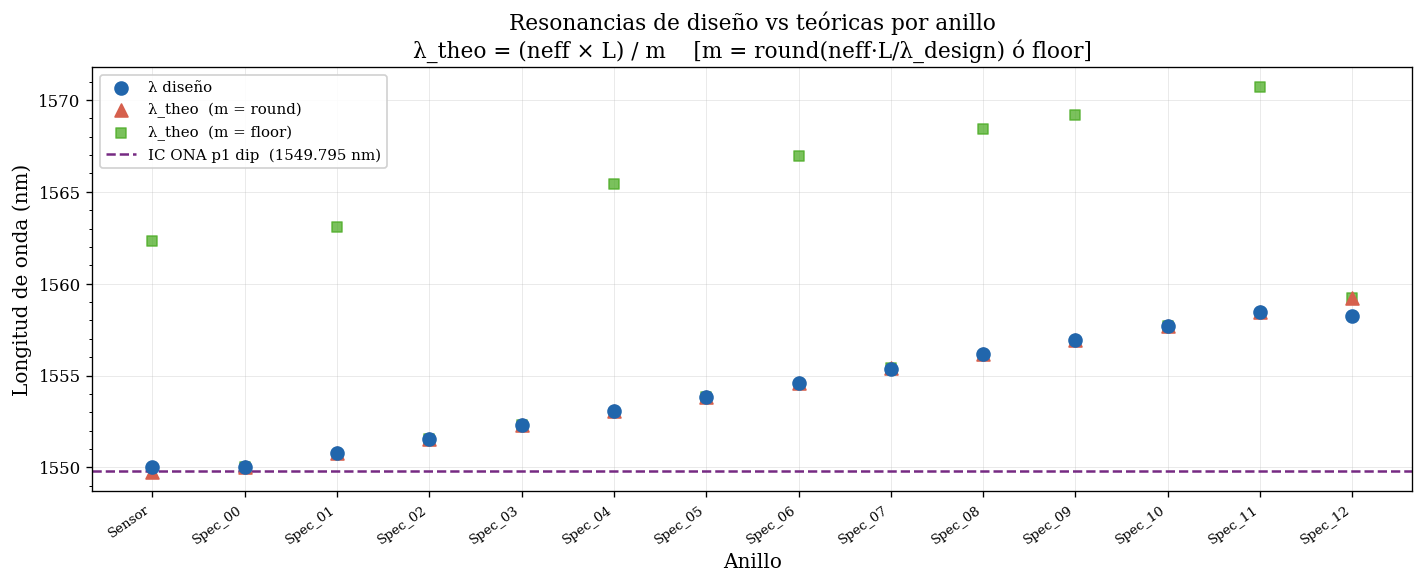

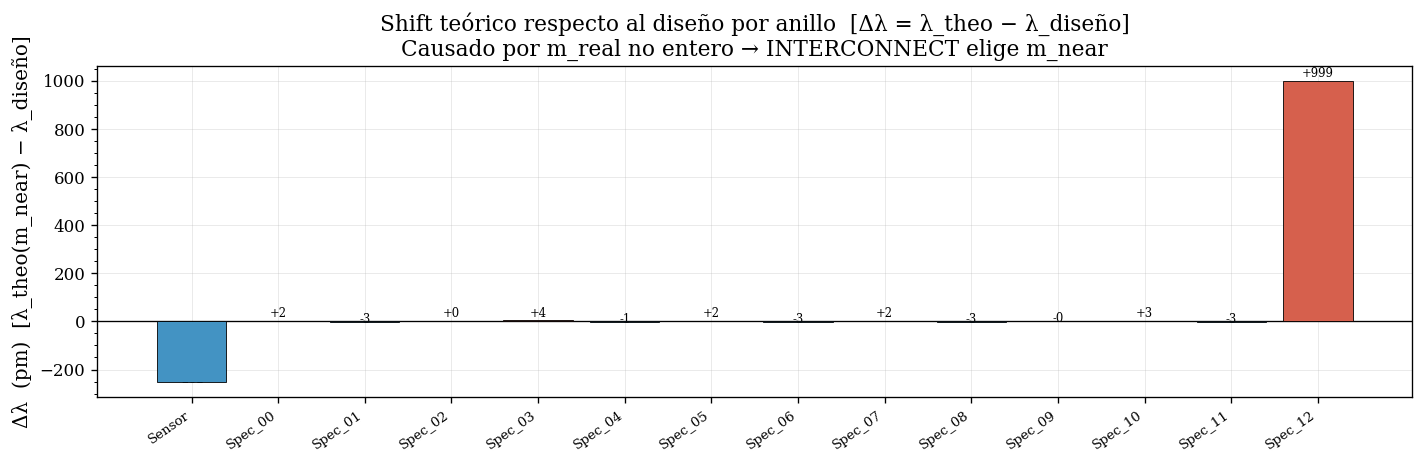

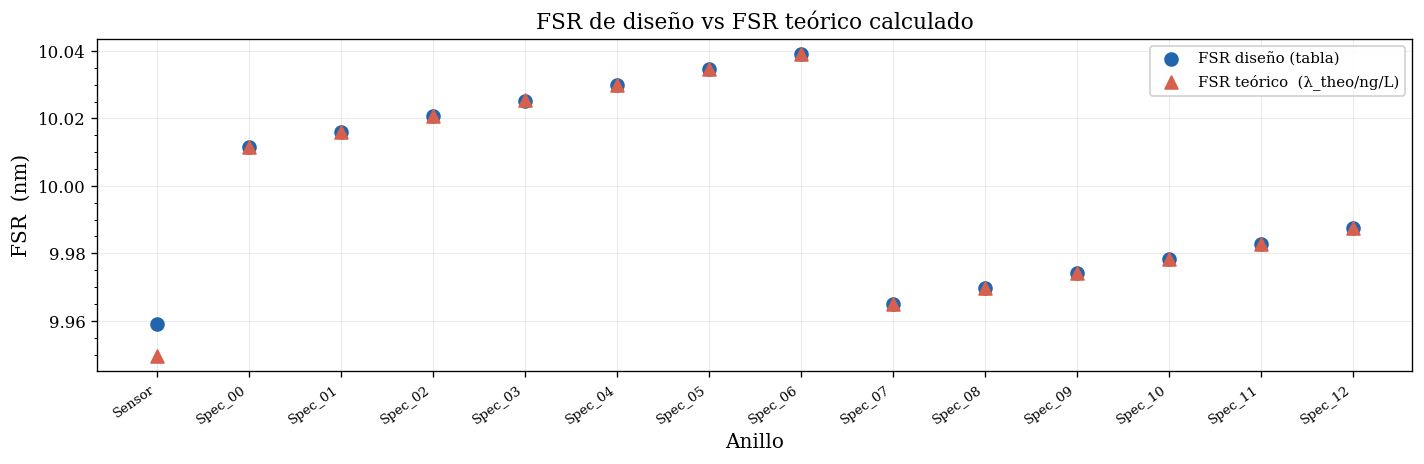

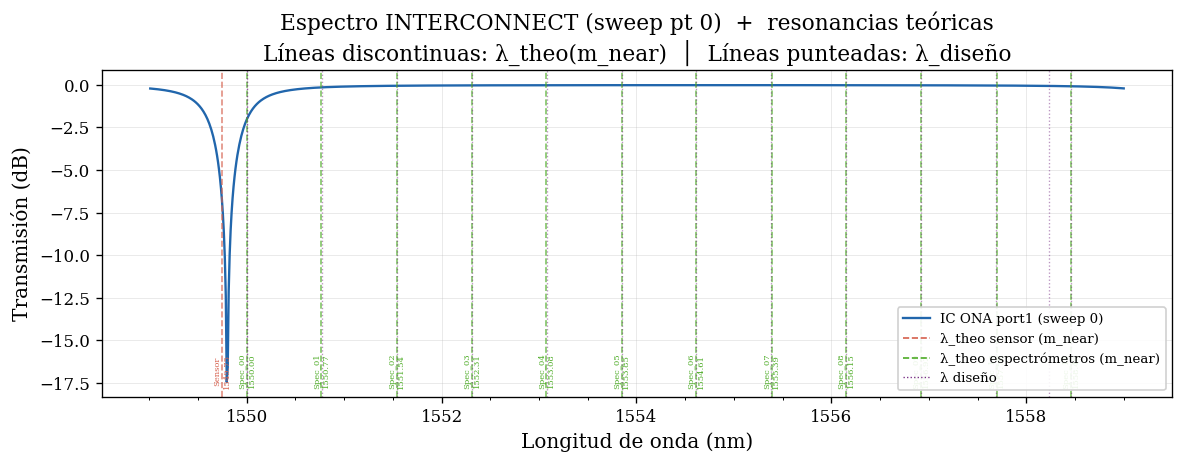

  Variable 'theo_results' disponible para celdas posteriores.


In [2]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 5 — Cálculo teórico de resonancias y comparación con INTERCONNECT    ║
# ║                                                                             ║
# ║  OBJETIVO                                                                   ║
# ║  ─────────────────────────────────────────────────────────────────────────  ║
# ║  Contrastar las longitudes de onda de resonancia teóricas (calculadas      ║
# ║  desde neff, ng y la circunferencia del anillo) con las obtenidas en       ║
# ║  INTERCONNECT, para diagnosticar el shift observado.                        ║
# ║                                                                             ║
# ║  DEPENDENCIAS HEREDADAS DEL SCRIPT PRINCIPAL                               ║
# ║  ─────────────────────────────────────────────────────────────────────────  ║
# ║  Todas las variables de parámetros del código anterior se reutilizan       ║
# ║  directamente (no se re-definen aquí):                                     ║
# ║    RING_RADIUS_M, RING_LAMBDA_RES_M, RING_NEFF_TE, RING_NG_TE,            ║
# ║    N_RINGS, SPEED_OF_LIGHT, wavelengths_m, T_port1_dB, T_port2_dB,        ║
# ║    computed, SWEEP_NEFF, SWEEP_NG, FIGURES_DIR                             ║
# ║                                                                             ║
# ║  FÍSICA UTILIZADA                                                           ║
# ║  ─────────────────────────────────────────────────────────────────────────  ║
# ║  Condición de resonancia de un anillo:                                     ║
# ║      λ_res = (neff × L) / m     [m: orden de modo, entero]                ║
# ║                                                                             ║
# ║  Para encontrar m a partir de los datos de diseño (neff, L, λ_target):    ║
# ║      m_real   = (neff × L) / λ_target                                      ║
# ║      m_near   = round(m_real)           ← entero más cercano               ║
# ║      m_floor  = floor(m_real)           ← entero inmediatamente inferior   ║
# ║                                                                             ║
# ║  Longitud de resonancia teórica para cada m candidato:                    ║
# ║      λ_theo(m) = (neff × L) / m                                            ║
# ║                                                                             ║
# ║  FSR teórico:                                                               ║
# ║      FSR_theo = λ_res² / (ng × L)                                          ║
# ║                                                                             ║
# ║  NOTA SOBRE EL ANILLO SENSOR                                               ║
# ║  ─────────────────────────────────────────────────────────────────────────  ║
# ║  Para el barrido paramétrico, se usa SWEEP_NEFF[0] / SWEEP_NG[0] como     ║
# ║  estado de referencia inicial del sensor (primer punto del sweep).         ║
# ║  El neff/ng de diseño nominal (RING_NEFF_TE[0]/RING_NG_TE[0]) también     ║
# ║  se muestra para comparación.                                              ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ─────────────────────────────────────────────────────────────────────────────
# Parámetros de diseño de la tabla original (TABLE 1)
# Solo se definen aquí los valores que NO provienen del código anterior:
#   FSR de diseño [nm] por anillo (en el mismo orden que RING_RADIUS_M)
# ─────────────────────────────────────────────────────────────────────────────
# FSR_DESIGN_NM[0]  = Sensor  (Ring 1)
# FSR_DESIGN_NM[1]  = Spec_00 (Ring 2)  ...  FSR_DESIGN_NM[13] = Spec_12 (Ring 14)
FSR_DESIGN_NM = np.array([
     9.9590,   # Sensor
    10.0116,   # Spec_00
    10.0161,   # Spec_01
    10.0207,   # Spec_02
    10.0253,   # Spec_03
    10.0299,   # Spec_04
    10.0346,   # Spec_05
    10.0392,   # Spec_06
     9.9650,   # Spec_07
     9.9696,   # Spec_08
     9.9742,   # Spec_09
     9.9783,   # Spec_10  ← "9.9783" interpolado entre 9.9742 y 9.9829
     9.9829,   # Spec_11
     9.9875,   # Spec_12
])

# Etiquetas de los anillos
RING_LABELS = (
    ["Sensor"] +
    [f"Spec_{i:02d}" for i in range(N_RINGS - 1)]
)

# ─────────────────────────────────────────────────────────────────────────────
# Para el anillo sensor se usan los valores del PRIMER PUNTO DEL SWEEP
# (estado de referencia: cladding = estado inicial de la medición)
# ─────────────────────────────────────────────────────────────────────────────
neff_sensor_sweep0 = float(SWEEP_NEFF[0])
ng_sensor_sweep0   = float(SWEEP_NG[0])

# Arrays de neff / ng que se usarán para el cálculo teórico (por anillo)
# Ring 0 (sensor) → primer punto del sweep
# Rings 1-13      → valores fijos de diseño (RING_NEFF_TE / RING_NG_TE)
neff_calc = RING_NEFF_TE.copy().astype(float)
ng_calc   = RING_NG_TE.copy().astype(float)
neff_calc[0] = neff_sensor_sweep0
ng_calc[0]   = ng_sensor_sweep0

# ─────────────────────────────────────────────────────────────────────────────
# Circunferencias [m]  (ya definidas en el código anterior como RING_RADIUS_M)
# ─────────────────────────────────────────────────────────────────────────────
L_m = RING_RADIUS_M * 2.0 * math.pi   # circumference [m]  shape (14,)

# ─────────────────────────────────────────────────────────────────────────────
# Longitudes de onda de resonancia de diseño [m]
# (heredadas directamente: RING_LAMBDA_RES_M)
# ─────────────────────────────────────────────────────────────────────────────
lambda_design_m  = RING_LAMBDA_RES_M.copy()
lambda_design_nm = lambda_design_m * 1e9

# ─────────────────────────────────────────────────────────────────────────────
# Cálculo teórico
# ─────────────────────────────────────────────────────────────────────────────
# Número de onda real (continuo) correspondiente al diseño
m_real  = (neff_calc * L_m) / lambda_design_m          # flotante
m_near  = np.round(m_real).astype(int)                 # entero más cercano
m_floor = np.floor(m_real).astype(int)                 # entero inferior

# λ_theo para m_near y m_floor [nm]
lambda_theo_near_m  = (neff_calc * L_m) / m_near
lambda_theo_floor_m = (neff_calc * L_m) / m_floor
lambda_theo_near_nm  = lambda_theo_near_m  * 1e9
lambda_theo_floor_nm = lambda_theo_floor_m * 1e9

# FSR teórico [nm]  — calculado en el estado de diseño
fsr_theo_near_nm  = (lambda_theo_near_nm**2)  / (ng_calc * L_m * 1e9)
fsr_theo_floor_nm = (lambda_theo_floor_nm**2) / (ng_calc * L_m * 1e9)

# FSR de diseño
fsr_design_nm = FSR_DESIGN_NM.copy()

# ─────────────────────────────────────────────────────────────────────────────
# Longitud de onda de resonancia extraída de la simulación INTERCONNECT
# Se usa el mínimo de T_port1_dB en el PRIMER punto válido del sweep
# (índice s=0 si está computado, si no el primer punto válido)
# ─────────────────────────────────────────────────────────────────────────────
# ONA port1 monitorea RING_1 through — el dip principal corresponde a
# la resonancia de RING_1 (sensor) en su estado sweep[0].
# ONA port2 monitorea RING_14 through — refleja la resonancia acumulada
# de toda la cascada.

lambda_ic_port1_nm = None
lambda_ic_port2_nm = None

try:
    # Usamos el primer punto del sweep (índice 0) — mismo estado que neff_calc[0]
    if computed[0] and wavelengths_m is not None:
        wl_nm_ref = wavelengths_m * 1e9
        dip1_idx  = int(np.argmin(T_port1_dB[0, :]))
        dip2_idx  = int(np.argmin(T_port2_dB[0, :]))
        lambda_ic_port1_nm = float(wl_nm_ref[dip1_idx])
        lambda_ic_port2_nm = float(wl_nm_ref[dip2_idx])
        print(f"  INTERCONNECT (sweep pt 0) — ONA port1 dip : {lambda_ic_port1_nm:.4f} nm")
        print(f"  INTERCONNECT (sweep pt 0) — ONA port2 dip : {lambda_ic_port2_nm:.4f} nm")
    else:
        print("  [AVISO] computed[0] = False o wavelengths_m no disponible.")
        print("          La columna 'IC (ONA p1)' aparecerá como N/A.")
except Exception as exc:
    print(f"  [AVISO] No se pudo extraer dip de INTERCONNECT: {exc}")

# ─────────────────────────────────────────────────────────────────────────────
# Construcción del DataFrame de comparación
# ─────────────────────────────────────────────────────────────────────────────
rows = []
for i in range(N_RINGS):
    # Diferencias λ_theo − λ_design
    delta_near_nm  = lambda_theo_near_nm[i]  - lambda_design_nm[i]
    delta_floor_nm = lambda_theo_floor_nm[i] - lambda_design_nm[i]

    # Error fraccional del m_real respecto al m_near
    frac_err = m_real[i] - m_near[i]   # cuán "descentrado" está m_real

    row = {
        "Ring"              : RING_LABELS[i],
        "λ_design (nm)"     : round(lambda_design_nm[i], 4),
        "neff"              : round(neff_calc[i], 6),
        "ng"                : round(ng_calc[i], 6),
        "L (µm)"            : round(L_m[i] * 1e6, 4),
        "m_real"            : round(m_real[i], 6),
        "m_near"            : int(m_near[i]),
        "λ_theo_mNear (nm)" : round(lambda_theo_near_nm[i], 4),
        "Δλ_mNear (pm)"     : round(delta_near_nm * 1e3, 2),
        "m_floor"           : int(m_floor[i]),
        "λ_theo_mFloor (nm)": round(lambda_theo_floor_nm[i], 4),
        "Δλ_mFloor (pm)"    : round(delta_floor_nm * 1e3, 2),
        "FSR_design (nm)"   : round(fsr_design_nm[i], 4),
        "FSR_theo_mNear (nm)": round(fsr_theo_near_nm[i], 4),
        "FSR_delta (pm)"    : round((fsr_theo_near_nm[i] - fsr_design_nm[i]) * 1e3, 2),
        "m_frac_err"        : round(frac_err, 6),
    }
    rows.append(row)

df = pd.DataFrame(rows)
df.set_index("Ring", inplace=True)

# ─────────────────────────────────────────────────────────────────────────────
# Impresión en consola — tabla de diagnóstico completa
# ─────────────────────────────────────────────────────────────────────────────
SEP = "═" * 130
print()
print(SEP)
print("  TABLA DE COMPARACIÓN TEÓRICA vs DISEÑO  │  14-Ring Cascade  │  SiN 400 nm × 1000 nm")
print(f"  Anillo sensor (Ring 1): neff = {neff_sensor_sweep0:.6f}  ng = {ng_sensor_sweep0:.6f}  "
      f"(primer punto del sweep; diseño: neff={RING_NEFF_TE[0]:.6f}, ng={RING_NG_TE[0]:.6f})")
print(SEP)

# Cabecera
hdr = (f"  {'Ring':<10}  {'λ_design':>11}  {'neff':>10}  {'L (µm)':>9}  "
       f"{'m_real':>10}  {'m_near':>7}  {'λ_mNear':>10}  {'Δλ_mNear':>11}  "
       f"{'m_floor':>8}  {'λ_mFloor':>11}  {'Δλ_mFloor':>12}  "
       f"{'FSR_des':>9}  {'FSR_teo':>9}  {'ΔFSR':>8}")
print(hdr)
print("  " + "─" * 126)
units = (f"  {'':10}  {'(nm)':>11}  {'':>10}  {'':>9}  "
         f"{'':>10}  {'':>7}  {'(nm)':>10}  {'(pm)':>11}  "
         f"{'':>8}  {'(nm)':>11}  {'(pm)':>12}  "
         f"{'(nm)':>9}  {'(nm)':>9}  {'(pm)':>8}")
print(units)
print("  " + "─" * 126)

for i in range(N_RINGS):
    lbl  = RING_LABELS[i]
    star = " ◄ SENSOR" if i == 0 else ""
    flag_near  = "  ✓" if abs(df.loc[lbl, "Δλ_mNear (pm)"])  < 500 else "  !"
    flag_floor = "  ✓" if abs(df.loc[lbl, "Δλ_mFloor (pm)"]) < 500 else "  !"
    print(
        f"  {lbl:<10}  "
        f"{df.loc[lbl, 'λ_design (nm)']:>11.4f}  "
        f"{df.loc[lbl, 'neff']:>10.6f}  "
        f"{df.loc[lbl, 'L (µm)']:>9.4f}  "
        f"{df.loc[lbl, 'm_real']:>10.4f}  "
        f"{df.loc[lbl, 'm_near']:>7d}  "
        f"{df.loc[lbl, 'λ_theo_mNear (nm)']:>10.4f}{flag_near}  "
        f"{df.loc[lbl, 'Δλ_mNear (pm)']:>+9.1f} pm  "
        f"{df.loc[lbl, 'm_floor']:>8d}  "
        f"{df.loc[lbl, 'λ_theo_mFloor (nm)']:>11.4f}{flag_floor}  "
        f"{df.loc[lbl, 'Δλ_mFloor (pm)']:>+10.1f} pm  "
        f"{df.loc[lbl, 'FSR_design (nm)']:>9.4f}  "
        f"{df.loc[lbl, 'FSR_theo_mNear (nm)']:>9.4f}  "
        f"{df.loc[lbl, 'FSR_delta (pm)']:>+7.1f} pm"
        f"{star}"
    )

print()

# ─────────────────────────────────────────────────────────────────────────────
# Sección de diagnóstico INTERCONNECT vs teórico (anillo sensor)
# ─────────────────────────────────────────────────────────────────────────────
print(SEP)
print("  DIAGNÓSTICO — INTERCONNECT vs Teoría  (anillo sensor, sweep pt 0)")
print(SEP)
print(f"  λ_design   (diseño)          : {lambda_design_nm[0]:.4f} nm")
print(f"  λ_theo     (m_near={m_near[0]:d})      : {lambda_theo_near_nm[0]:.4f} nm   "
      f"Δ = {(lambda_theo_near_nm[0]-lambda_design_nm[0])*1e3:+.2f} pm")
print(f"  λ_theo     (m_floor={m_floor[0]:d})    : {lambda_theo_floor_nm[0]:.4f} nm   "
      f"Δ = {(lambda_theo_floor_nm[0]-lambda_design_nm[0])*1e3:+.2f} pm")
print(f"  m_real                       : {m_real[0]:.6f}   (fracción: {m_real[0]-m_near[0]:+.6f})")

if lambda_ic_port1_nm is not None:
    delta_ic_vs_design = lambda_ic_port1_nm - lambda_design_nm[0]
    delta_ic_vs_theo   = lambda_ic_port1_nm - lambda_theo_near_nm[0]
    print(f"  λ_IC       (ONA port1 dip)   : {lambda_ic_port1_nm:.4f} nm")
    print(f"    → Δ(IC − diseño)           : {delta_ic_vs_design*1e3:+.2f} pm")
    print(f"    → Δ(IC − theo m_near)      : {delta_ic_vs_theo*1e3:+.2f} pm")
    if abs(delta_ic_vs_design) > 0.05:
        print()
        print("  ⚠  SHIFT DETECTADO > 50 pm entre diseño e INTERCONNECT.")
        print("     Posibles causas:")
        print("     1. INTERCONNECT resuelve m = round(m_real) pero con neff re-evaluado")
        print("        en la frecuencia central (dispersión), no en λ_design.")
        print("     2. La propiedad 'frequency' se fija en c/λ_design, pero INTERCONNECT")
        print("        itera internamente hasta convergencia con neff(λ) → shift residual.")
        print("     3. Las pérdidas (101 dB/m) ensanchan la resonancia y desplazan el")
        print("        mínimo aparente de transmisión respecto al centro Lorentziano.")
        print("     4. El valor de m_real no es entero exacto → INTERCONNECT elige el")
        f"        m más cercano, produciendo Δλ = {(lambda_theo_near_nm[0]-lambda_design_nm[0])*1e3:+.2f} pm."
        print(f"        m más cercano: Δλ = {(lambda_theo_near_nm[0]-lambda_design_nm[0])*1e3:+.2f} pm.")
else:
    print("  λ_IC (ONA port1)             : N/A — sweep no ejecutado aún")

print(SEP)

# ─────────────────────────────────────────────────────────────────────────────
# Sección de diagnóstico para TODOS los anillos espectrómetros
# ─────────────────────────────────────────────────────────────────────────────
print()
print("  RESUMEN ESPECTRÓMETROS — Δλ (teoría m_near − diseño) [pm]")
print("  " + "─" * 65)
for i in range(N_RINGS):
    lbl   = RING_LABELS[i]
    delta = df.loc[lbl, "Δλ_mNear (pm)"]
    bar   = "█" * int(abs(delta) / 50)
    sign  = "+" if delta >= 0 else "-"
    print(f"  {lbl:<10}  {delta:>+8.1f} pm  {bar}")
print()

# ─────────────────────────────────────────────────────────────────────────────
# FIGURA 1 — λ_design vs λ_theo (m_near) vs λ_theo (m_floor) para todos los anillos
# ─────────────────────────────────────────────────────────────────────────────
fig_th, ax_th = plt.subplots(figsize=(12, 5))
x = np.arange(N_RINGS)

ax_th.scatter(x, lambda_design_nm,       marker="o", s=60,  zorder=6,
              color="#2166ac", label="λ diseño")
ax_th.scatter(x, lambda_theo_near_nm,    marker="^", s=60,  zorder=5,
              color="#d6604d", label="λ_theo  (m = round)")
ax_th.scatter(x, lambda_theo_floor_nm,   marker="s", s=40,  zorder=4,
              color="#4dac26", label="λ_theo  (m = floor)", alpha=0.75)

if lambda_ic_port1_nm is not None:
    ax_th.axhline(lambda_ic_port1_nm, color="#762a83", lw=1.5, ls="--",
                  label=f"IC ONA p1 dip  ({lambda_ic_port1_nm:.3f} nm)")

ax_th.set_xticks(x)
ax_th.set_xticklabels(RING_LABELS, rotation=35, ha="right", fontsize=8)
ax_th.set_ylabel("Longitud de onda (nm)")
ax_th.set_xlabel("Anillo")
ax_th.set_title(
    "Resonancias de diseño vs teóricas por anillo\n"
    "λ_theo = (neff × L) / m    [m = round(neff·L/λ_design) ó floor]"
)
ax_th.legend(framealpha=0.9, fontsize=9)
ax_th.yaxis.set_minor_locator(ticker.AutoMinorLocator())
fig_th.tight_layout()
fig_th.savefig(FIGURES_DIR / "theoretical_lambda_vs_design.png", dpi=200)
fig_th.savefig(FIGURES_DIR / "theoretical_lambda_vs_design.pdf")
print(f"  Guardada → theoretical_lambda_vs_design.png/pdf")

# ─────────────────────────────────────────────────────────────────────────────
# FIGURA 2 — Δλ (pm) por anillo: cuantifica el shift teórico vs diseño
# ─────────────────────────────────────────────────────────────────────────────
fig_d, ax_d = plt.subplots(figsize=(12, 4))
bars = ax_d.bar(x, df["Δλ_mNear (pm)"].values,
                color=["#d6604d" if v >= 0 else "#4393c3"
                       for v in df["Δλ_mNear (pm)"].values],
                edgecolor="k", linewidth=0.5, zorder=4)
ax_d.axhline(0, color="k", lw=0.8, ls="-")
ax_d.set_xticks(x)
ax_d.set_xticklabels(RING_LABELS, rotation=35, ha="right", fontsize=8)
ax_d.set_ylabel("Δλ  (pm)  [λ_theo(m_near) − λ_diseño]")
ax_d.set_title(
    "Shift teórico respecto al diseño por anillo  [Δλ = λ_theo − λ_diseño]\n"
    "Causado por m_real no entero → INTERCONNECT elige m_near"
)
for bar, val in zip(bars, df["Δλ_mNear (pm)"].values):
    ax_d.text(bar.get_x() + bar.get_width() / 2, val + (5 if val >= 0 else -15),
              f"{val:+.0f}", ha="center", va="bottom", fontsize=7)
ax_d.yaxis.set_minor_locator(ticker.AutoMinorLocator())
fig_d.tight_layout()
fig_d.savefig(FIGURES_DIR / "delta_lambda_theoretical_vs_design.png", dpi=200)
fig_d.savefig(FIGURES_DIR / "delta_lambda_theoretical_vs_design.pdf")
print(f"  Guardada → delta_lambda_theoretical_vs_design.png/pdf")

# ─────────────────────────────────────────────────────────────────────────────
# FIGURA 3 — FSR de diseño vs FSR teórico
# ─────────────────────────────────────────────────────────────────────────────
fig_fsr, ax_fsr = plt.subplots(figsize=(12, 4))
ax_fsr.scatter(x, fsr_design_nm,     marker="o", s=60, zorder=5,
               color="#2166ac",  label="FSR diseño (tabla)")
ax_fsr.scatter(x, fsr_theo_near_nm,  marker="^", s=60, zorder=5,
               color="#d6604d",  label="FSR teórico  (λ_theo/ng/L)")

ax_fsr.set_xticks(x)
ax_fsr.set_xticklabels(RING_LABELS, rotation=35, ha="right", fontsize=8)
ax_fsr.set_ylabel("FSR  (nm)")
ax_fsr.set_xlabel("Anillo")
ax_fsr.set_title("FSR de diseño vs FSR teórico calculado")
ax_fsr.legend(framealpha=0.9, fontsize=9)
ax_fsr.yaxis.set_minor_locator(ticker.AutoMinorLocator())
fig_fsr.tight_layout()
fig_fsr.savefig(FIGURES_DIR / "fsr_design_vs_theoretical.png", dpi=200)
fig_fsr.savefig(FIGURES_DIR / "fsr_design_vs_theoretical.pdf")
print(f"  Guardada → fsr_design_vs_theoretical.png/pdf")

# ─────────────────────────────────────────────────────────────────────────────
# FIGURA 4 — Comparación espectral ONA port1 (sweep pt 0) vs λ_theo
#            (solo si INTERCONNECT ya corrió)
# ─────────────────────────────────────────────────────────────────────────────
if lambda_ic_port1_nm is not None and wavelengths_m is not None:
    fig_sp, ax_sp = plt.subplots(figsize=(10, 4))
    wl_nm_ref = wavelengths_m * 1e9
    ax_sp.plot(wl_nm_ref, T_port1_dB[0, :],
               color="#2166ac", lw=1.4, label="IC ONA port1 (sweep pt 0)")

    # Marcar resonancias teóricas de todos los anillos que caen en la ventana
    wl_min, wl_max = wl_nm_ref.min(), wl_nm_ref.max()
    for i in range(N_RINGS):
        lbl = RING_LABELS[i]
        lw  = lambda_theo_near_nm[i]
        if wl_min <= lw <= wl_max:
            color_i = "#d6604d" if i == 0 else "#4dac26"
            ax_sp.axvline(lw, color=color_i, lw=1.0, ls="--", alpha=0.7)
            ax_sp.text(lw, ax_sp.get_ylim()[0] + 0.5,
                       f"{lbl}\n{lw:.2f}", fontsize=5, ha="center",
                       color=color_i, rotation=90, va="bottom")
        ld = lambda_design_nm[i]
        if wl_min <= ld <= wl_max:
            ax_sp.axvline(ld, color="#762a83", lw=0.8, ls=":", alpha=0.5)

    from matplotlib.lines import Line2D
    legend_elems = [
        Line2D([0], [0], color="#2166ac", lw=1.4, label="IC ONA port1 (sweep 0)"),
        Line2D([0], [0], color="#d6604d", lw=1.0, ls="--", label="λ_theo sensor (m_near)"),
        Line2D([0], [0], color="#4dac26", lw=1.0, ls="--", label="λ_theo espectrómetros (m_near)"),
        Line2D([0], [0], color="#762a83", lw=0.8, ls=":",  label="λ diseño"),
    ]
    ax_sp.legend(handles=legend_elems, fontsize=8, framealpha=0.9, loc="lower right")
    ax_sp.set_xlabel("Longitud de onda (nm)")
    ax_sp.set_ylabel("Transmisión (dB)")
    ax_sp.set_title(
        "Espectro INTERCONNECT (sweep pt 0)  +  resonancias teóricas\n"
        "Líneas discontinuas: λ_theo(m_near)  │  Líneas punteadas: λ_diseño"
    )
    ax_sp.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    fig_sp.tight_layout()
    fig_sp.savefig(FIGURES_DIR / "spectrum_ic_vs_theoretical_resonances.png", dpi=200)
    fig_sp.savefig(FIGURES_DIR / "spectrum_ic_vs_theoretical_resonances.pdf")
    print(f"  Guardada → spectrum_ic_vs_theoretical_resonances.png/pdf")

# ─────────────────────────────────────────────────────────────────────────────
# Exportar tabla a CSV para referencia externa
# ─────────────────────────────────────────────────────────────────────────────
csv_path = DATA_DIR / f"{VERSION_NAME}_theoretical_comparison.csv"
df.to_csv(csv_path, float_format="%.6f")
print(f"\n  CSV exportado → {csv_path}")
print(f"  Figuras       → {FIGURES_DIR}")
print()

plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Exponer variables para posible uso en celdas posteriores
# ─────────────────────────────────────────────────────────────────────────────
theo_results = dict(
    lambda_design_nm     = lambda_design_nm,
    lambda_theo_near_nm  = lambda_theo_near_nm,
    lambda_theo_floor_nm = lambda_theo_floor_nm,
    fsr_design_nm        = fsr_design_nm,
    fsr_theo_near_nm     = fsr_theo_near_nm,
    m_real               = m_real,
    m_near               = m_near,
    m_floor              = m_floor,
    neff_used            = neff_calc,
    ng_used              = ng_calc,
    L_m                  = L_m,
    df_table             = df,
)

print("  Variable 'theo_results' disponible para celdas posteriores.")

# ═════════════════════════════════════════════════════════════════════════════
#  END CELL 5
# ═════════════════════════════════════════════════════════════════════════════